In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import os
from scipy.interpolate import interp1d
import time
from scipy.ndimage import distance_transform_edt, map_coordinates


Map data loaded successfully.
Grid map shape: (585, 514)
Number of raceline points: 203


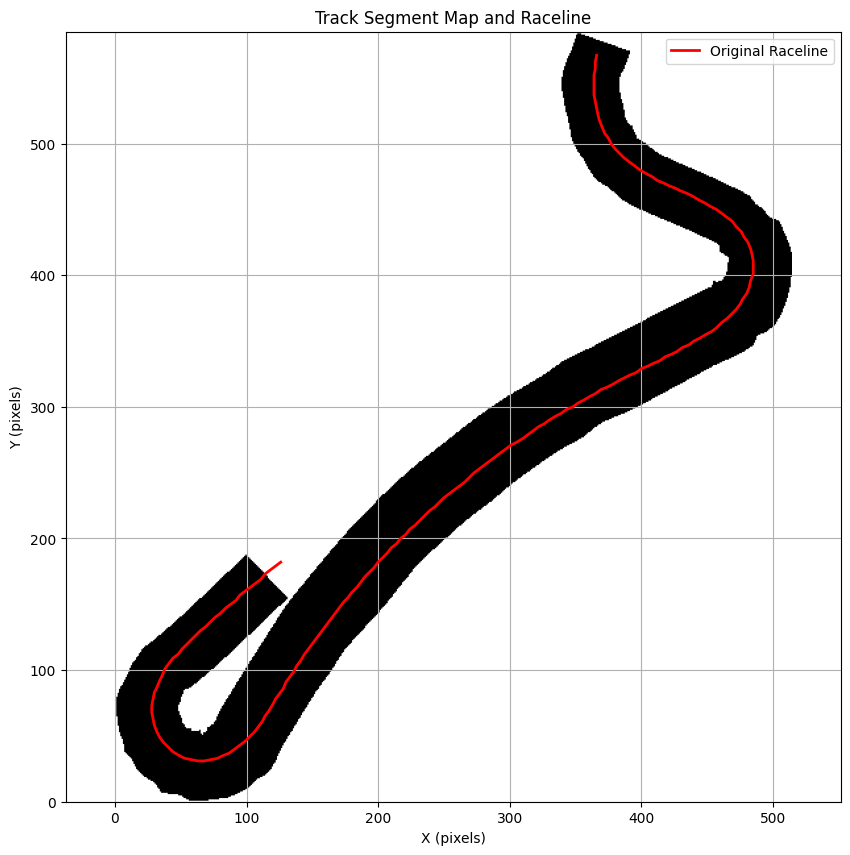

In [14]:
# Load Map Data from the .npz file
map_path = 'nuerburgring_segment_map.npz'

if not os.path.exists(map_path):
    print(f"Map file not found at '{map_path}'")
    print("Please run 'research/UniCon/create_track_map.py' first to generate the map file.")
    # As a fallback for the rest of the notebook, create dummy data.
    grid_map = np.zeros((100, 100))
    raceline_grid = np.array([np.linspace(10, 90, 100), np.linspace(10, 90, 100)]).T
    resolution = 1.0
    translation_offset = np.array([0, 0])
    print("Using dummy data to proceed.")
else:
    map_data = np.load(map_path)
    grid_map = map_data['grid_map']
    raceline_grid = map_data['raceline_grid']
    resolution = map_data['resolution']
    translation_offset = map_data['translation_offset']
    print("Map data loaded successfully.")

print(f"Grid map shape: {grid_map.shape}")
print(f"Number of raceline points: {len(raceline_grid)}")

# Visualize the map and the original raceline
plt.figure(figsize=(10, 10))
plt.imshow(grid_map, cmap='gray', origin='lower', extent=[0, grid_map.shape[1], 0, grid_map.shape[0]])
plt.plot(raceline_grid[:, 0], raceline_grid[:, 1], 'r-', linewidth=2, label='Original Raceline')
plt.title('Track Segment Map and Raceline')
plt.xlabel('X (pixels)')
plt.ylabel('Y (pixels)')
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()


In [15]:
# --- Kinematic bicycle (pixel units; resolution = pixels/m) ---
def simulate_vehicle_bc(x0, u_seq, dt, state_steps, L_pix=2.7, v_max=None, delta_rate_max=None):
    """
    x = [x, y, theta, v]; u = [a, delta]
    theta_dot = v / L * tan(delta)
    """
    control_steps = u_seq.shape[0]
    states = np.zeros((state_steps, 4))
    states[0] = x0[:4]  # Ignore original r

    last_delta = 0.0
    for k in range(control_steps):
        x, y, theta, v = states[k]
        a, delta = u_seq[k]

        # Limit steering rate change (optional, for better convergence)
        if delta_rate_max is not None:
            delta = np.clip(delta, last_delta - delta_rate_max * dt, last_delta + delta_rate_max * dt)
        last_delta = delta

        v_next = v + dt * a
        if v_max is not None:
            v_next = np.clip(v_next, 0.0, v_max)

        theta_dot = v_next / L_pix * np.tan(delta)
        theta_next = theta + dt * theta_dot

        x_next = x + dt * v_next * np.cos(theta)
        y_next = y + dt * v_next * np.sin(theta)

        states[k+1] = [x_next, y_next, theta_next, v_next]

    return states

# Reparameterize control variables using tanh to avoid boundary issues
def unpack_controls(z_flat, control_steps, a_max, delta_max):
    z = z_flat.reshape(control_steps, 2)
    a = a_max * np.tanh(z[:, 0])
    delta = delta_max * np.tanh(z[:, 1])
    return np.column_stack([a, delta])

def build_sdf_from_grid(grid):
    g = grid.astype(np.float32)
    g = (g - g.min()) / (g.max() - g.min() + 1e-8)   # Normalize to [0,1]
    # Track is "black" -> small values; auto-threshold at 0.5 is robust
    inside_mask = g < 0.5
    # Positive distance inside, negative outside
    d_in  = distance_transform_edt(inside_mask)
    d_out = distance_transform_edt(~inside_mask)
    sdf = d_in - d_out
    return sdf, inside_mask

def sample_sdf_bilinear(sdf, xy):
    # xy: [N,2] with columns [x,y] in pixel coordinates
    # map_coordinates requires order [row(y), col(x)]
    coords = np.vstack([xy[:,1], xy[:,0]])
    return map_coordinates(sdf, coords, order=1, mode='nearest')


In [16]:
# Setup of Parameters and Reference Trajectory

# Define the horizon for the optimal control problem
state_steps = 101
control_steps = state_steps - 1

# Calculate the geometric length of the raceline in pixels
path_length_pixels = np.sum(np.linalg.norm(np.diff(raceline_grid, axis=0), axis=1))
print(f"Total raceline length: {path_length_pixels:.2f} pixels.")
if resolution > 0:
    print(f"Assuming {resolution:.2f} pixels/meter, the length is approx {path_length_pixels/resolution:.2f} meters.")

# --- Adjust vehicle dynamics parameters based on the track ---
dt = 0.2  # Time step in seconds
total_time = control_steps * dt
# Required average speed to cover the distance in the given time
avg_speed_pixels = path_length_pixels / total_time
print(f"To finish in {total_time}s, target average speed: {avg_speed_pixels:.2f} pixels/s.")

# Set dynamic constraints based on the required speed (HIGHLY RELAXED CONSTRAINTS)
v_target = avg_speed_pixels * 2.0  # Further increased target speed factor
a_max = 35.0  # pixels/s^2, much higher acceleration capability
delta_max = 1.0  # rad, allows for very sharp turns (~57 degrees)

print("\nSetting dynamic parameters (HIGHLY RELAXED):")
print(f"  dt = {dt}s")
print(f"  Control Steps = {control_steps}")
print(f"  Max Acceleration (a_max) = {a_max:.2f} pixels/s^2")
print(f"  Max Steering (delta_max) = {delta_max:.2f} rad ({delta_max*180/np.pi:.1f} degrees)")

# --- Create the reference trajectory ---
# The solver needs a target point for each time step. We resample the original raceline.
arc_length = np.concatenate(([0], np.cumsum(np.linalg.norm(np.diff(raceline_grid, axis=0), axis=1))))
f_x = interp1d(arc_length, raceline_grid[:, 0], kind='cubic')
f_y = interp1d(arc_length, raceline_grid[:, 1], kind='cubic')
target_arc_length = np.linspace(0, arc_length[-1], state_steps)
raceline_ref = np.vstack([f_x(target_arc_length), f_y(target_arc_length)]).T

# --- Define Initial State (4D for bicycle model) ---
x0_pos = raceline_ref[0]
dx = raceline_ref[1, 0] - raceline_ref[0, 0]
dy = raceline_ref[1, 1] - raceline_ref[0, 1]
theta0 = np.arctan2(dy, dx)
x0 = np.array([x0_pos[0], x0_pos[1], theta0, 0.0]) # [x, y, theta, v]

print(f"\nInitial state (x0): {np.round(x0, 2)}")

# --- Additional References for the new Cost Function ---
# Reference heading for terminal constraint
dxy = np.diff(raceline_ref, axis=0, append=raceline_ref[-1:])
theta_ref = np.arctan2(dxy[:,1], dxy[:,0])

# Reference velocity profile to track (HIGHLY RELAXED)
v_max = 3.5 * avg_speed_pixels # Much higher maximum velocity
v_ref = np.clip(np.linspace(0, 2.0*avg_speed_pixels, state_steps), 0, v_max)

# --- Build Signed Distance Field (SDF) for track constraints ---
sdf_map, track_mask = build_sdf_from_grid(grid_map)
# Set safety margin in pixels. 8-12 pixels is a conservative choice.
safety_margin_pix = 10.0
w_safety = 40.0   # Weight for the safety constraint

# Optional: Visualize the SDF
# plt.figure(figsize=(10,10)); plt.imshow(sdf_map, origin='lower'); plt.colorbar(); plt.title('Signed Distance Field'); plt.show()


Total raceline length: 1012.59 pixels.
Assuming 1.00 pixels/meter, the length is approx 1012.59 meters.
To finish in 20.0s, target average speed: 50.63 pixels/s.

Setting dynamic parameters (HIGHLY RELAXED):
  dt = 0.2s
  Control Steps = 100
  Max Acceleration (a_max) = 35.00 pixels/s^2
  Max Steering (delta_max) = 1.00 rad (57.3 degrees)

Initial state (x0): [366.   567.    -1.67   0.  ]


In [17]:
# Optimal Control Cost Function (Reparameterized)
def cost_function_reparam(z_flat, x0, raceline_ref, theta_ref, v_ref, dt,
                          state_steps, control_steps, a_max, delta_max,
                          L_pix=2.7, v_max=None,
                          sdf_map=None, safety_margin_pix=8.0, w_safety=40.0):
    u_seq = unpack_controls(z_flat, control_steps, a_max, delta_max)
    states = simulate_vehicle_bc(x0, u_seq, dt, state_steps, L_pix=L_pix, v_max=v_max, delta_rate_max=2.5)  # Much higher steering rate

    # Weights
    w_path = 5.0
    w_u = 1e-3
    w_smooth = 0.05
    w_v = 0.02
    w_terminal = 30.0

    # 1) Path tracking error
    pos_err = states[:, :2] - raceline_ref
    J_path = np.sum(np.einsum('ij,ij->i', pos_err, pos_err))

    # 2) Control effort + smoothness
    J_u = np.sum(u_seq**2)
    du = np.diff(u_seq, axis=0)
    J_smooth = np.sum(du**2)

    # 3) Velocity reference tracking
    J_v = np.sum((states[:, 3] - v_ref)**2)

    # 4) Terminal position/heading
    term_pos = np.sum((states[-1, :2] - raceline_ref[-1])**2)
    dtheta = (states[-1, 2] - theta_ref[-1] + np.pi) % (2*np.pi) - np.pi
    J_term = term_pos + 0.1 * dtheta**2

    # 5) Safety constraint using an inverse barrier function
    J_safe = 0.0
    if sdf_map is not None:
        sdf_vals = sample_sdf_bilinear(sdf_map, states[:, :2])
        clear = sdf_vals - safety_margin_pix # Clearance > 0 is safe
        eps = 1.0 # Minimum clearance (pixels) to avoid divergence
        phi = 1.0 / np.maximum(clear, eps)**2 # Inverse barrier (approx. 1/clear^2)
        J_safe = np.sum(phi)


    J = (w_path*J_path + w_u*J_u + w_smooth*J_smooth +
         w_v*J_v + w_terminal*J_term + w_safety*J_safe)
    return float(J)


In [18]:
# Solve with Inverse Barrier and Continuation Method

# --- Optimizer Setup ---
num_decision_vars = control_steps * 2
z0 = np.zeros(num_decision_vars) # Initial guess for z is zero

print("Solving with inverse barrier and continuation method...")
start_time = time.time()

# --- Run the Optimizer with Continuation ---
# This loop gradually increases the safety weight to find a robust solution.
#w_safety_schedule = [10.0, 50.0, 200.0, 800.0]
w_safety_schedule = [100.0, 800.0, 3200.0, 12800.0, 51200.0]

for i, w_safety_current in enumerate(w_safety_schedule):
    print(f"\n--- Continuation Step {i+1}/{len(w_safety_schedule)}: w_safety = {w_safety_current} ---")
    res = minimize(
        cost_function_reparam,
        z0,
        args=(x0, raceline_ref, theta_ref, v_ref, dt, state_steps, control_steps, a_max, delta_max, 2.7*resolution, v_max,
              sdf_map, safety_margin_pix, w_safety_current),
        method="L-BFGS-B",
        options={"maxiter": 400, "maxfun": 200000, "ftol": 1e-6, "gtol": 1e-5, "maxls": 50, "disp": True}
    )
    z0 = res.x  # Warm start for the next iteration

end_time = time.time()
print(f"\nTotal optimization finished in {end_time - start_time:.2f} seconds.")

if res.success:
    print("Optimization succeeded.")
    u_optimal = unpack_controls(res.x, control_steps, a_max, delta_max)
    states_optimal = simulate_vehicle_bc(x0, u_optimal, dt, state_steps, L_pix=2.7*resolution, v_max=v_max)
else:
    print("Optimization message:", res.message)
    u_optimal = unpack_controls(res.x, control_steps, a_max, delta_max)
    states_optimal = simulate_vehicle_bc(x0, u_optimal, dt, state_steps, L_pix=2.7*resolution, v_max=v_max)


Solving with inverse barrier and continuation method...

--- Continuation Step 1/5: w_safety = 100.0 ---

--- Continuation Step 2/5: w_safety = 800.0 ---

--- Continuation Step 3/5: w_safety = 3200.0 ---

--- Continuation Step 4/5: w_safety = 12800.0 ---

--- Continuation Step 5/5: w_safety = 51200.0 ---

Total optimization finished in 260.06 seconds.
Optimization succeeded.


Plotting results from the successful optimization...


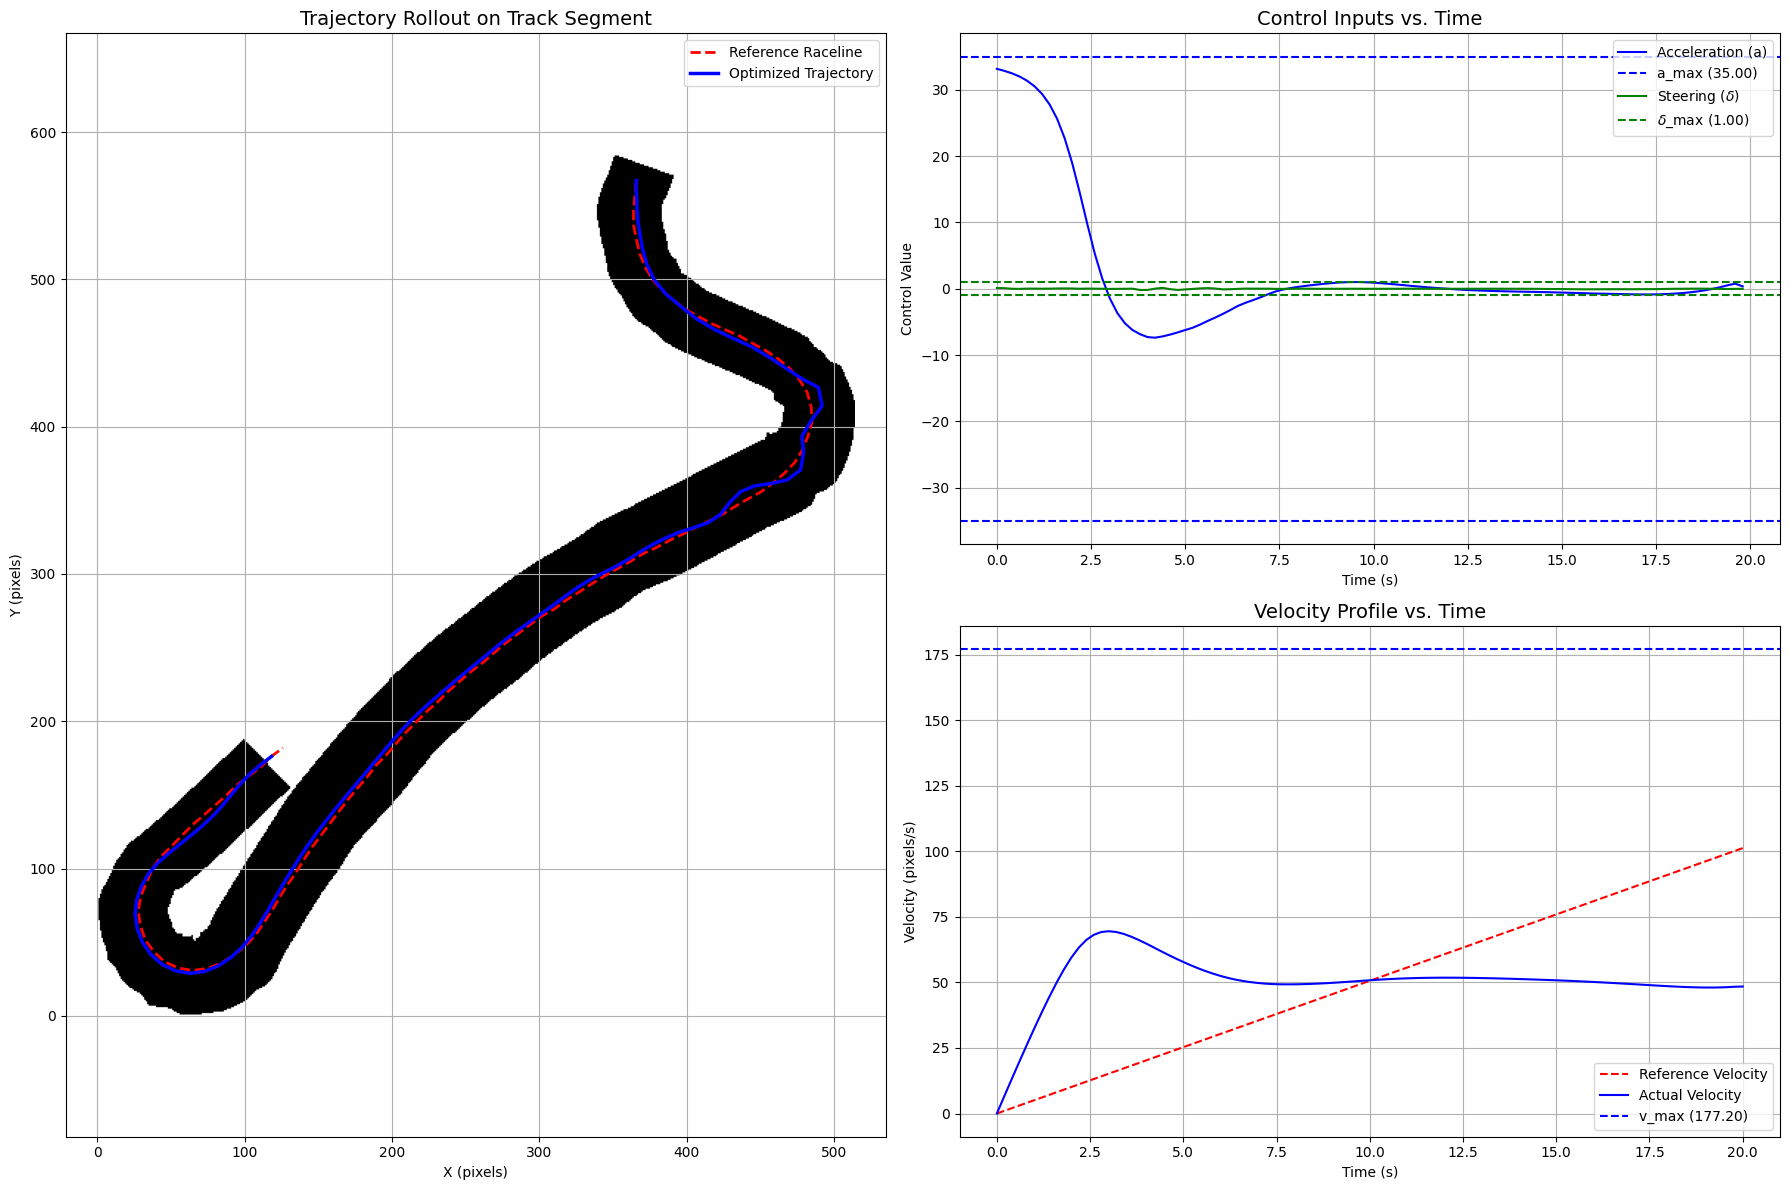

In [19]:
# --- Visualization of the Results ---
# This cell plots the optimized trajectory, control inputs, and velocity profile.

def plot_results(states, u_seq, raceline_ref, v_ref, grid_map, dt, control_steps, a_max, delta_max):
    t_arr_states = np.arange(states.shape[0]) * dt
    t_arr_controls = np.arange(u_seq.shape[0]) * dt

    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(2, 2)

    # 1) Trajectory on the map (larger plot)
    ax1 = fig.add_subplot(gs[:, 0])
    ax1.imshow(grid_map, cmap='gray', origin='lower', extent=[0, grid_map.shape[1], 0, grid_map.shape[0]])
    ax1.plot(raceline_ref[:, 0], raceline_ref[:, 1], 'r--', linewidth=2, label='Reference Raceline')
    ax1.plot(states[:, 0], states[:, 1], 'b-', linewidth=2.5, label='Optimized Trajectory')
    ax1.set_title('Trajectory Rollout on Track Segment', fontsize=14)
    ax1.set_xlabel('X (pixels)')
    ax1.set_ylabel('Y (pixels)')
    ax1.legend()
    ax1.axis('equal')
    ax1.grid(True)

    # 2) Control inputs
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(t_arr_controls, u_seq[:, 0], 'b-', label=f'Acceleration (a)')
    ax2.axhline(y=a_max, color='b', linestyle='--', label=f'a_max ({a_max:.2f})')
    ax2.axhline(y=-a_max, color='b', linestyle='--')
    ax2.plot(t_arr_controls, u_seq[:, 1], 'g-', label=f'Steering ($\\delta$)')
    ax2.axhline(y=delta_max, color='g', linestyle='--', label=f'$\\delta$_max ({delta_max:.2f})')
    ax2.axhline(y=-delta_max, color='g', linestyle='--')
    ax2.set_title('Control Inputs vs. Time', fontsize=14)
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel('Control Value')
    ax2.legend()
    ax2.grid(True)
    
    # 3) Velocity profile
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.plot(t_arr_states, v_ref, 'r--', label='Reference Velocity')
    ax3.plot(t_arr_states, states[:, 3], 'b-', label='Actual Velocity')
    ax3.axhline(y=v_max, color='b', linestyle='--', label=f'v_max ({v_max:.2f})')
    ax3.set_title('Velocity Profile vs. Time', fontsize=14)
    ax3.set_xlabel('Time (s)')
    ax3.set_ylabel('Velocity (pixels/s)')
    ax3.legend()
    ax3.grid(True)

    plt.tight_layout()
    plt.show()

if res.success:
    print("Plotting results from the successful optimization...")
    plot_results(states_optimal, u_optimal, raceline_ref, v_ref, grid_map, dt, control_steps, a_max, delta_max)
else:
    print("Plotting results from the optimization (may not be optimal)...")
    plot_results(states_optimal, u_optimal, raceline_ref, v_ref, grid_map, dt, control_steps, a_max, delta_max)



Polishing with MPPI (local refine, OCP-aligned)...
[MPPI] iter 05/30  J_best=1.286e+05  sig=(0.180,0.100)
[MPPI] iter 10/30  J_best=1.286e+05  sig=(0.153,0.085)
[MPPI] iter 15/30  J_best=1.286e+05  sig=(0.130,0.072)
[MPPI] iter 20/30  J_best=1.286e+05  sig=(0.111,0.061)
[MPPI] iter 25/30  J_best=1.286e+05  sig=(0.094,0.052)
[MPPI] iter 30/30  J_best=1.286e+05  sig=(0.080,0.044)
MPPI best J  : 1.286e+05
Min clearance before: -16.02 px | after: -9.24 px

--- Plotting MPPI Results ---


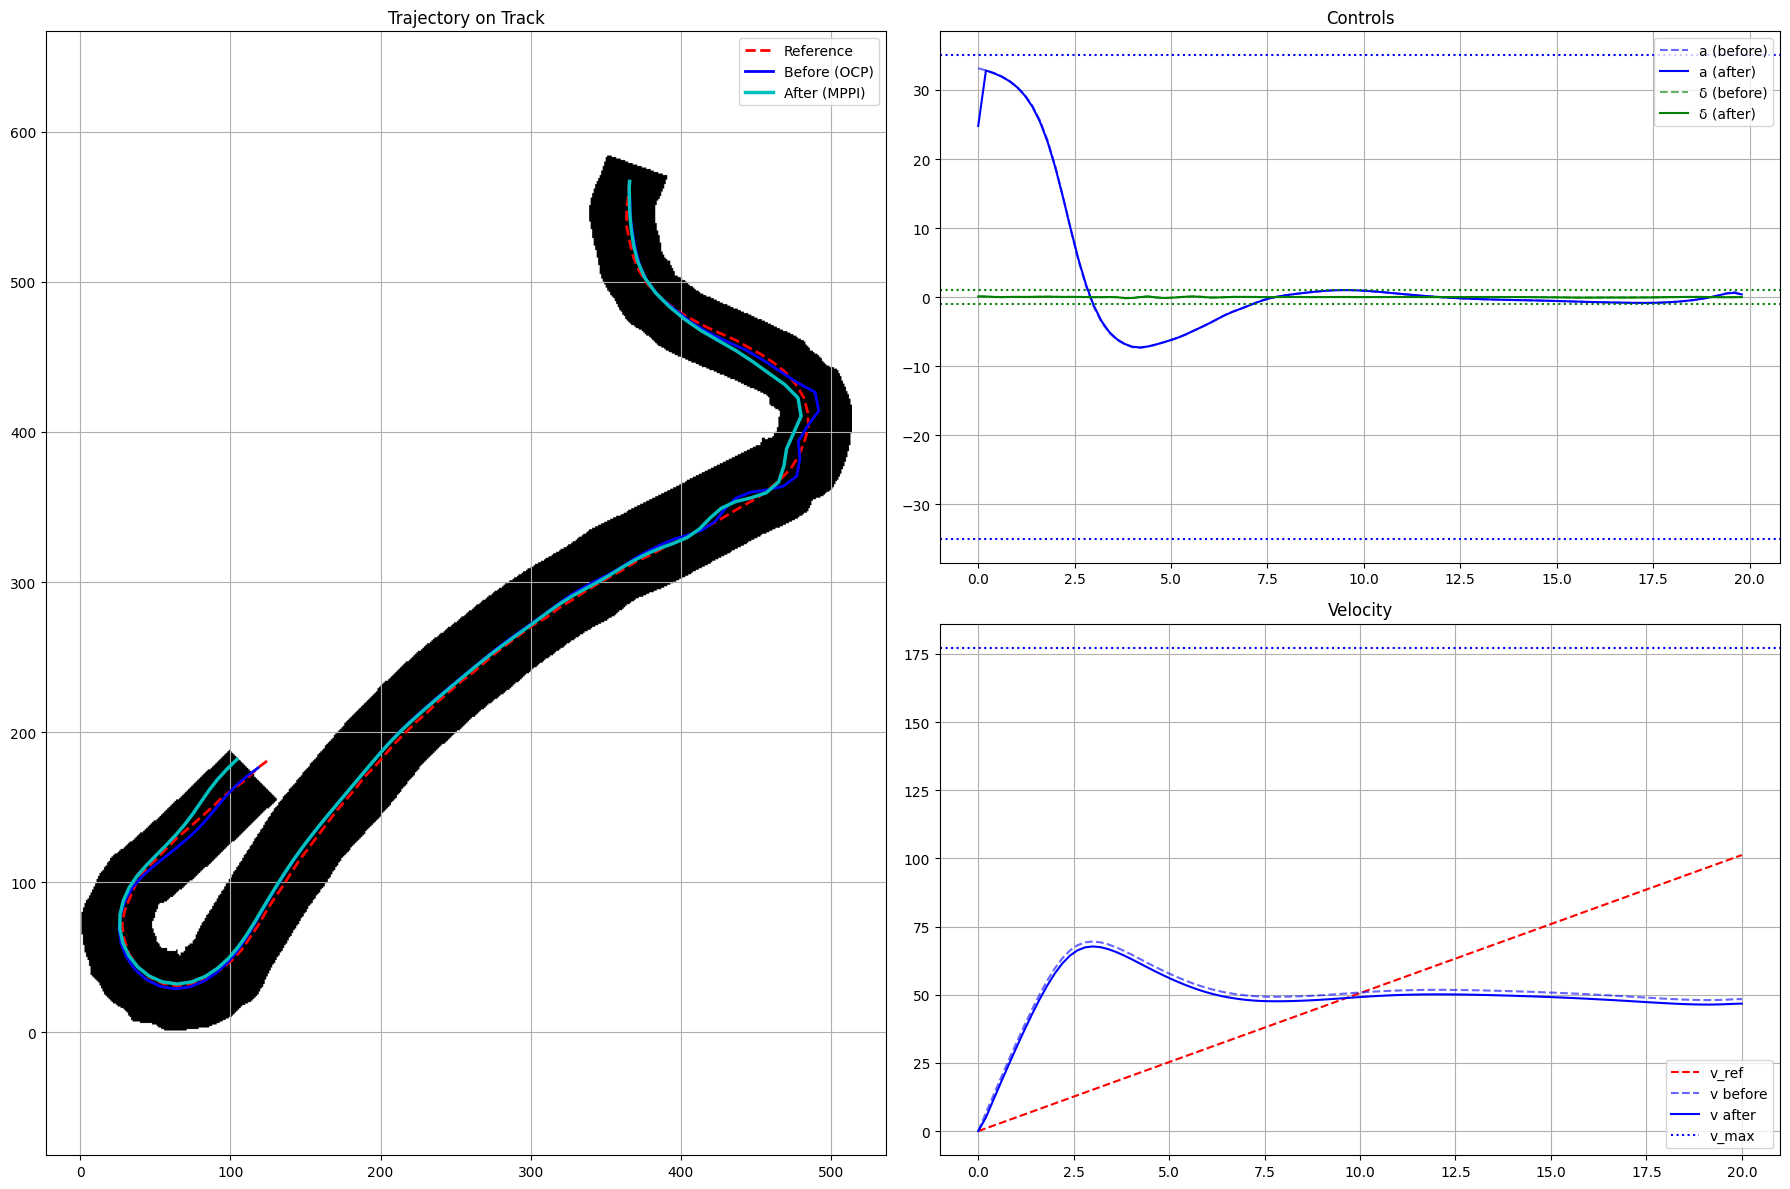

In [20]:
# ===================== MPPI (local refine, OCP-aligned) =====================
import numpy as np
import matplotlib.pyplot as plt

# ---- helpers ----
def atanh_clip(x, eps=1e-6):
    x = np.clip(x, -1+eps, 1-eps)
    return np.arctanh(x)

def lowpass_controls(u, passes=2):
    if passes <= 0: return u
    k = np.array([1.0, 2.0, 1.0]) / 4.0
    out = u.copy()
    for _ in range(passes):
        for j in range(2):
            out[:, j] = np.convolve(out[:, j], k, mode='same')
    return out

# ---- OCP-aligned cost (与上面的 OCP 保持一致 + 轻量速度/进度项) ----
def rollout_cost_ocp_aligned(states, u_seq, raceline_ref, theta_ref, v_ref,
                             # 与 OCP 同步的权重
                             w_path=5.0, w_u=1e-3, w_smooth=0.05,
                             w_v=0.12, w_terminal=30.0,
                             # inverse-barrier 安全项
                             sdf_map=None, safety_margin_pix=10.0, w_safety=1.5e4,
                             # 轻量“别停”与“往前走”引导（可按需微调/关掉）
                             v_min_factor=0.35, w_vmin=0.08, w_prog=120.0):
    # 1) 路径
    pos_err = states[:, :2] - raceline_ref
    J_path = np.sum(np.einsum('ij,ij->i', pos_err, pos_err))
    # 2) 控制能量与平滑
    J_u = np.sum(u_seq**2)
    J_smooth = np.sum(np.diff(u_seq, axis=0)**2)
    # 3) 速度
    J_v = np.sum((states[:, 3] - v_ref)**2)
    # 4) 末端
    term_pos = np.sum((states[-1, :2] - raceline_ref[-1])**2)
    dtheta = (states[-1, 2] - theta_ref[-1] + np.pi) % (2*np.pi) - np.pi
    J_term = term_pos + 0.1 * dtheta**2
    # 5) inverse-barrier 安全
    J_safe = 0.0
    if sdf_map is not None:
        sdf_vals = sample_sdf_bilinear(sdf_map, states[:, :2])
        clear = sdf_vals - safety_margin_pix
        phi = 1.0 / np.maximum(clear, 1.0)**2
        J_safe = np.sum(phi)
    # 6) 速度下限（防止停车取巧）
    v_min = v_min_factor * avg_speed_pixels
    J_vmin = np.sum(np.maximum(0.0, v_min - states[:, 3])**2)
    # 7) 进度（末端离终点的弧长差）
    idx = np.argmin(np.sum((raceline_ref - states[-1, :2])**2, axis=1))
    J_prog = (len(raceline_ref) - 1 - idx)**2

    J = (w_path*J_path + w_u*J_u + w_smooth*J_smooth +
         w_v*J_v + w_terminal*J_term + w_safety*J_safe +
         w_vmin*J_vmin + w_prog*J_prog)
    return float(J)

# ---- MPPI（小信赖域，本地微调；只采样动作） ----
def mppi_local_refine(u_base, x0,
                      iters=25, N=2048,
                      # 采样在 z-space，保持在 tanh 的线性区
                      sigma_z_a=0.18, sigma_z_delta=0.10,
                      # 时间相关噪声（温和）
                      rho=0.85,
                      # 信赖域：相对基准 z 的最大偏移 & 每次步长裁剪
                      z_tr_clip=0.35, z_step_clip=0.20,
                      # MPPI 温度 & 步长
                      lam=3000.0, step_size=0.9,
                      # 平滑与盒约束
                      smooth_passes=2,
                      # 动力学（与 OCP 对齐）
                      L_pix=None, v_max=None, delta_rate_max=2.5,
                      # 代价参数
                      cost_kwargs=None):
    assert u_base.ndim == 2 and u_base.shape[1] == 2
    T = u_base.shape[0]
    if L_pix is None: L_pix = 2.7 * resolution

    # 基准 z（tanh 逆）
    z0 = np.zeros_like(u_base)
    z0[:, 0] = atanh_clip(u_base[:, 0] / a_max)
    z0[:, 1] = atanh_clip(u_base[:, 1] / delta_max)

    # 当前均值 = 基准
    z_mean = z0.copy()

    # 评估基线
    states_best = simulate_vehicle_bc(x0, u_base, dt, T+1, L_pix=L_pix, v_max=v_max, delta_rate_max=delta_rate_max)
    J_best = rollout_cost_ocp_aligned(states_best, u_base, raceline_ref, theta_ref, v_ref,
                                      sdf_map=sdf_map, safety_margin_pix=safety_margin_pix, **(cost_kwargs or {}))
    u_best = u_base.copy()

    for it in range(iters):
        # 生成时间相关噪声（独立 2 维）
        eps = np.random.randn(N, T, 2)
        for k in range(1, T):
            eps[:, k, :] = rho * eps[:, k-1, :] + np.sqrt(1-rho**2) * eps[:, k, :]
        eps[:, :, 0] *= sigma_z_a
        eps[:, :, 1] *= sigma_z_delta

        # z-samples + 信赖域约束
        z_samp = z_mean[None, :, :] + eps
        z_samp = z0[None, :, :] + np.clip(z_samp - z0[None, :, :], -z_tr_clip, z_tr_clip)

        # 映射到动作、平滑、裁到盒
        u_samp = np.empty_like(z_samp)
        u_samp[:, :, 0] = a_max   * np.tanh(z_samp[:, :, 0])
        u_samp[:, :, 1] = delta_max * np.tanh(z_samp[:, :, 1])
        if smooth_passes > 0:
            for i in range(N):
                u_samp[i] = lowpass_controls(u_samp[i], passes=smooth_passes)
        u_samp[:, :, 0] = np.clip(u_samp[:, :, 0], -a_max, a_max)
        u_samp[:, :, 1] = np.clip(u_samp[:, :, 1], -delta_max, delta_max)

        # 评估
        costs = np.empty(N, dtype=np.float64)
        for i in range(N):
            states_i = simulate_vehicle_bc(x0, u_samp[i], dt, T+1, L_pix=L_pix, v_max=v_max, delta_rate_max=delta_rate_max)
            costs[i] = rollout_cost_ocp_aligned(
                states_i, u_samp[i], raceline_ref, theta_ref, v_ref,
                sdf_map=sdf_map, safety_margin_pix=safety_margin_pix, **(cost_kwargs or {})
            )

        # MPPI 权重
        Jmin = np.min(costs)
        w = np.exp(-(costs - Jmin) / lam)
        S = np.sum(w) + 1e-12

        # 加权更新（限制步长）
        dz = (w[:, None, None] * (z_samp - z_mean[None, :, :])).sum(axis=0) / S
        dz = np.clip(dz, -z_step_clip, +z_step_clip)
        z_mean = z_mean + step_size * dz
        # 继续施加信赖域
        z_mean = z0 + np.clip(z_mean - z0, -z_tr_clip, z_tr_clip)

        # 记录最好
        i_best = np.argmin(costs)
        if costs[i_best] < J_best:
            J_best = float(costs[i_best])
            u_best = u_samp[i_best].copy()
            states_best = simulate_vehicle_bc(x0, u_best, dt, T+1, L_pix=L_pix, v_max=v_max, delta_rate_max=delta_rate_max)

        # 自适应降噪：若改进慢，缩小方差
        if (it+1) % 6 == 0:
            sigma_z_a *= 0.85
            sigma_z_delta *= 0.85

        if (it+1) % 5 == 0:
            print(f"[MPPI] iter {it+1:02d}/{iters}  J_best={J_best:.3e}  sig=({sigma_z_a:.3f},{sigma_z_delta:.3f})")

    # 输出：再做一次平滑与盒约束
    u_best = lowpass_controls(u_best, passes=1)
    u_best[:, 0] = np.clip(u_best[:, 0], -a_max, a_max)
    u_best[:, 1] = np.clip(u_best[:, 1], -delta_max, delta_max)
    states_best = simulate_vehicle_bc(x0, u_best, dt, T+1, L_pix=L_pix, v_max=v_max, delta_rate_max=delta_rate_max)
    return u_best, states_best, J_best

print("Polishing with MPPI (local refine, OCP-aligned)...")
u_mppi, states_mppi, J_mppi = mppi_local_refine(
    u_optimal, x0,
    iters=30, N=2048,
    sigma_z_a=0.18, sigma_z_delta=0.10,
    rho=0.85, z_tr_clip=0.35, z_step_clip=0.20,
    lam=3000.0, step_size=0.9,
    smooth_passes=2,
    L_pix=2.7*resolution, v_max=v_max, delta_rate_max=2.5,   # 与 OCP 对齐！
    cost_kwargs=dict(  # 适度提高速度与进度比重，防止“停车取巧”
        w_v=0.12, w_safety=1.5e4, v_min_factor=0.35, w_vmin=0.08, w_prog=120.0
    )
)

# 诊断对比
pre_clear  = sample_sdf_bilinear(sdf_map, states_optimal[:, :2]) - safety_margin_pix
post_clear = sample_sdf_bilinear(sdf_map, states_mppi[:, :2])    - safety_margin_pix
print(f"MPPI best J  : {J_mppi:.3e}")
print(f"Min clearance before: {np.min(pre_clear):.2f} px | after: {np.min(post_clear):.2f} px")

# 简单对比可视化
def plot_mppi_results(states_pre, u_pre, states_post, u_post,
                      raceline_ref, v_ref, grid_map, dt, a_max, delta_max, v_max):
    t_s = np.arange(states_post.shape[0]) * dt
    t_u = np.arange(u_post.shape[0]) * dt

    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(2, 2)

    ax1 = fig.add_subplot(gs[:, 0])
    ax1.imshow(grid_map, cmap='gray', origin='lower',
               extent=[0, grid_map.shape[1], 0, grid_map.shape[0]])
    ax1.plot(raceline_ref[:,0], raceline_ref[:,1], 'r--', lw=2, label='Reference')
    ax1.plot(states_pre[:,0],  states_pre[:,1],  'b-', lw=2.0, label='Before (OCP)')
    ax1.plot(states_post[:,0], states_post[:,1], 'c-', lw=2.5, label='After (MPPI)')
    ax1.axis('equal'); ax1.grid(True); ax1.legend(); ax1.set_title('Trajectory on Track')

    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(t_u, u_pre[:,0],  'b--', alpha=0.6, label='a (before)')
    ax2.plot(t_u, u_post[:,0], 'b-',  label='a (after)')
    ax2.axhline(a_max, color='b', ls=':'); ax2.axhline(-a_max, color='b', ls=':')
    ax2.plot(t_u, u_pre[:,1],  'g--', alpha=0.6, label='δ (before)')
    ax2.plot(t_u, u_post[:,1], 'g-',  label='δ (after)')
    ax2.axhline(delta_max, color='g', ls=':'); ax2.axhline(-delta_max, color='g', ls=':')
    ax2.grid(True); ax2.legend(); ax2.set_title('Controls')

    ax3 = fig.add_subplot(gs[1, 1])
    ax3.plot(t_s, v_ref, 'r--', label='v_ref')
    ax3.plot(t_s, states_pre[:,3],  'b--', alpha=0.6, label='v before')
    ax3.plot(t_s, states_post[:,3], 'b-',  label='v after')
    ax3.axhline(v_max, color='b', ls=':', label='v_max')
    ax3.grid(True); ax3.legend(); ax3.set_title('Velocity')

    plt.tight_layout(); plt.show()

print("\n--- Plotting MPPI Results ---")
plot_mppi_results(states_optimal, u_optimal, states_mppi, u_mppi,
                  raceline_ref, v_ref, grid_map, dt, a_max, delta_max, v_max)


=== START  ===

 A: (349.3, 572.1)
 B: (382.7, 561.9)

=== END  ===

A' (120.70, 153.80)
B' (95.90, 178.50)


=== Randomized OCP on segment ===
Start sampled @ [357.94629708 563.41042412]  -> nearest idx 1
End   sampled @ [112.67496725 166.98078094]    -> nearest idx 198
Segment length: 987.49 px | avg target speed: 49.37 px/s

--- Continuation Step 1/5: w_safety = 100.0 ---

--- Continuation Step 2/5: w_safety = 800.0 ---

--- Continuation Step 3/5: w_safety = 3200.0 ---

--- Continuation Step 4/5: w_safety = 12800.0 ---

--- Continuation Step 5/5: w_safety = 51200.0 ---


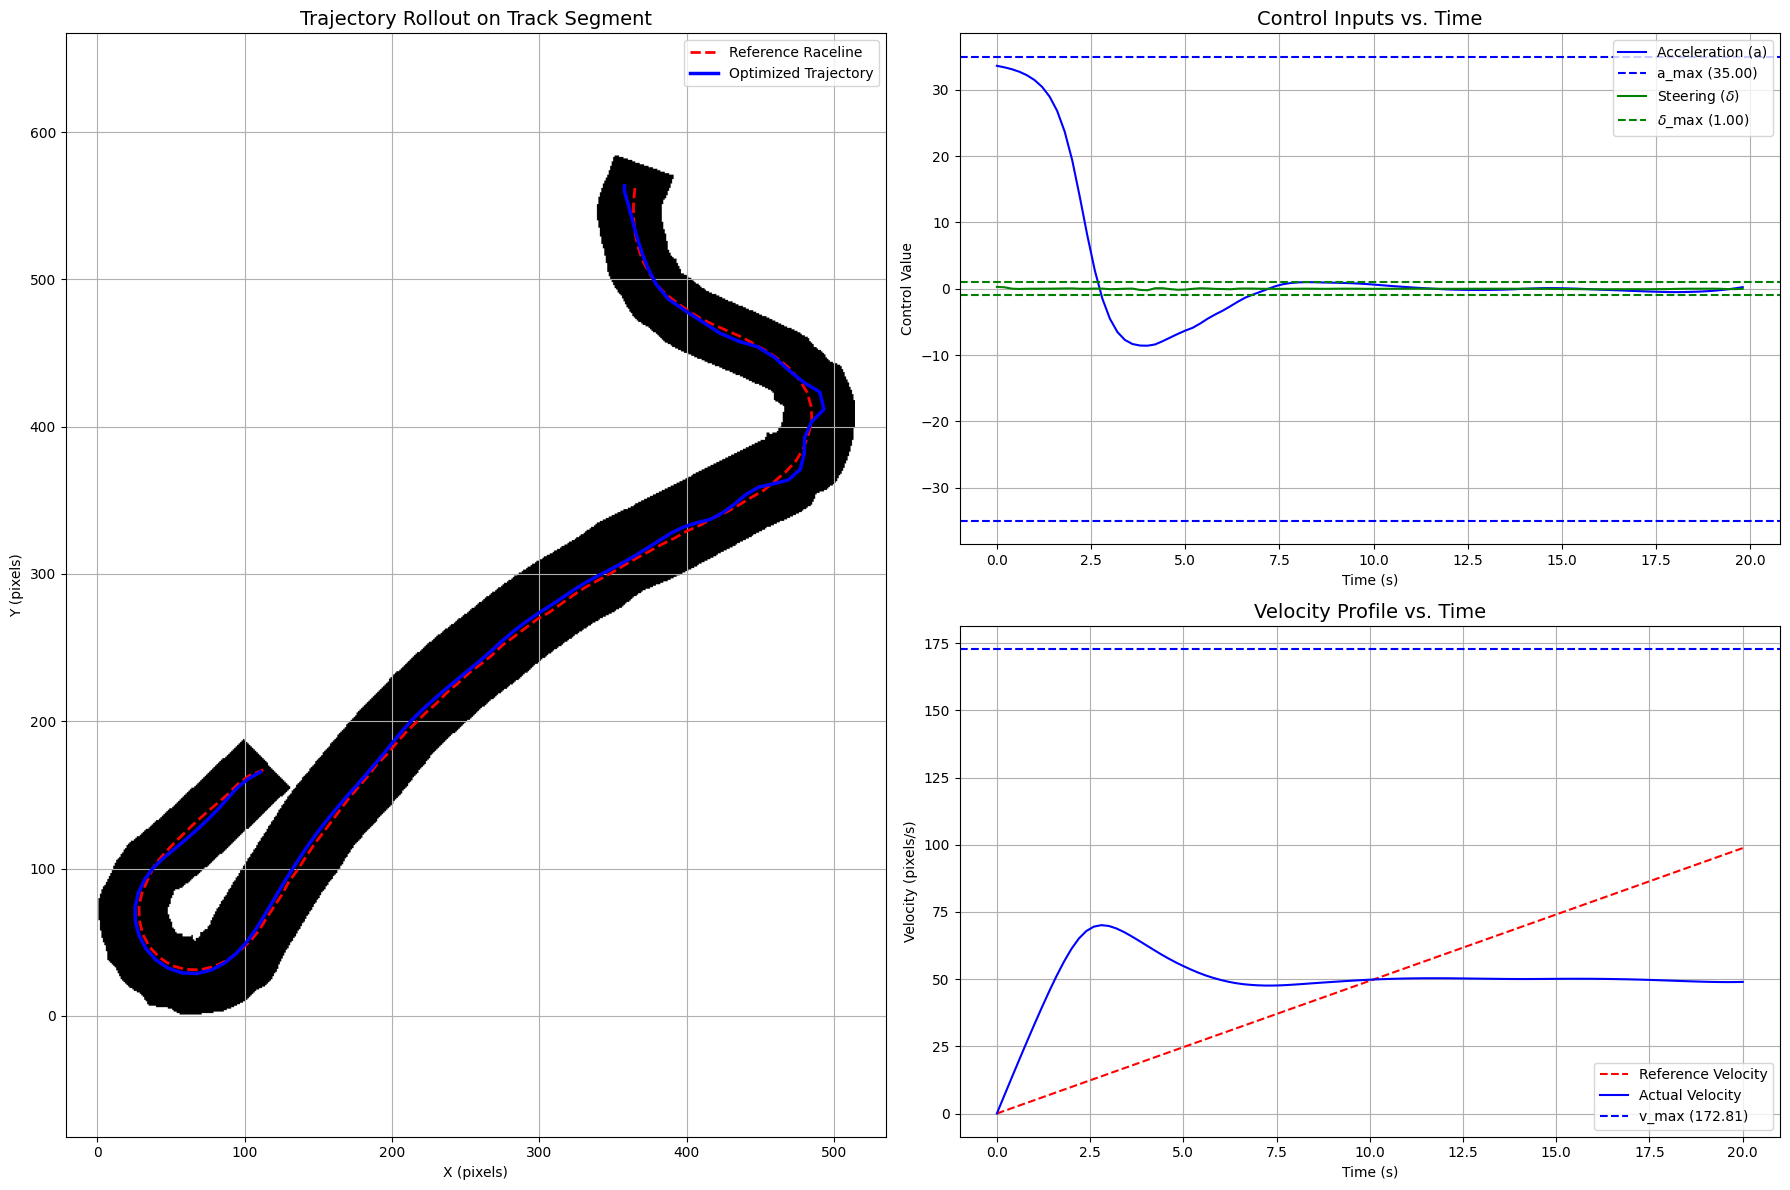

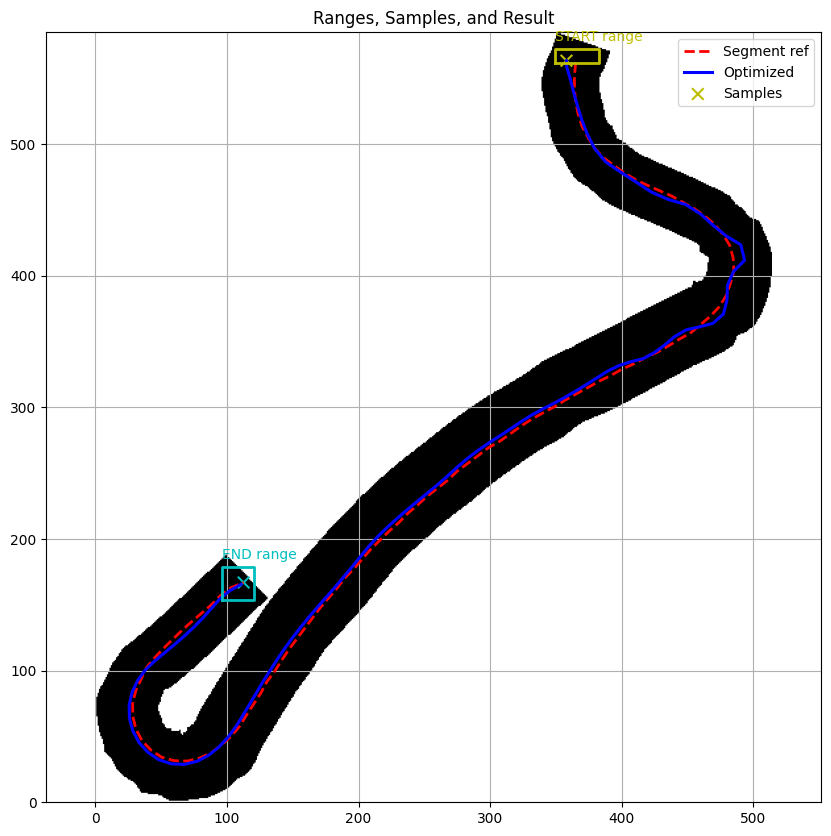

In [21]:
# %% [Randomized start/end segment OCP solve — same pipeline, locked start, strong terminal pull]
import numpy as np
import matplotlib.pyplot as plt

# ---- 1) 定义起终点矩形范围（两角点）----
START_A = np.array([349.3, 572.1])
START_B = np.array([382.7, 561.9])

END_A   = np.array([120.70, 153.80])
END_B   = np.array([95.90,  178.50])

# 可选：设定随机种子以复现
SEED = None  # 例如填 42；或保持 None 每次不同
rng = np.random.default_rng(SEED)

def sample_in_box(P, Q, rng):
    lo = np.minimum(P, Q)
    hi = np.maximum(P, Q)
    return rng.uniform(lo, hi)

def nearest_index(points, target_xy):
    # points: (N,2)
    d2 = np.sum((points - target_xy[None, :])**2, axis=1)
    return int(np.argmin(d2))

def resample_polyline_to_N(pts, N):
    # pts: (M,2) polyline; return N-point cubic arclength resample
    s = np.concatenate(([0.0], np.cumsum(np.linalg.norm(np.diff(pts, axis=0), axis=1))))
    fx = interp1d(s, pts[:, 0], kind='cubic')
    fy = interp1d(s, pts[:, 1], kind='cubic')
    s_new = np.linspace(0.0, s[-1], N)
    return np.vstack([fx(s_new), fy(s_new)]).T, s[-1]

# ---- 2) 随机采样并构造子段参考 ----
start_sample = sample_in_box(START_A, START_B, rng)   # 起点锁为采样点
end_sample   = sample_in_box(END_A,   END_B,   rng)   # 终点采样点（将对 OCP 有强吸引）

# 在全局 raceline_grid 上找与采样点最近的索引，用于确定 raceline 子段走向
idx_s = nearest_index(raceline_grid, start_sample)
idx_e = nearest_index(raceline_grid, end_sample)
if idx_s == idx_e:
    idx_e = min(idx_s + 1, len(raceline_grid) - 1)

if idx_s < idx_e:
    sub_poly = raceline_grid[idx_s:idx_e + 1]
else:
    # 若方向相反，则反转以保持沿轨迹单调前进
    sub_poly = raceline_grid[idx_e:idx_s + 1][::-1]

# 将 raceline 子段等弧长重采样为与 OCP 一致的 state_steps
raceline_ref_seg, seg_len_px = resample_polyline_to_N(sub_poly, state_steps)

# 【强吸引终点】：将参考末点直接替换为随机采样的终点（不在中心线上也行）
raceline_ref_seg[-1] = end_sample

# 方向参考（与主流程一致）
dxy_seg = np.diff(raceline_ref_seg, axis=0, append=raceline_ref_seg[-1:])
theta_ref_seg = np.arctan2(dxy_seg[:, 1], dxy_seg[:, 0])

# 速度参考（与主流程一致，但基于子段长度）
avg_speed_pix_seg = seg_len_px / (control_steps * dt + 1e-12)
v_max_seg = 3.5 * avg_speed_pix_seg
v_ref_seg = np.clip(np.linspace(0, 2.0 * avg_speed_pix_seg, state_steps), 0, v_max_seg)

# ---- 3) 起点“锁死”为采样点；朝向用参考切向；初速置 0 ----
theta0_seg = np.arctan2(raceline_ref_seg[1, 1] - raceline_ref_seg[0, 1],
                        raceline_ref_seg[1, 0] - raceline_ref_seg[0, 0])
x0_seg = np.array([start_sample[0], start_sample[1], theta0_seg, 0.0])

# ---- 4) 续接法求解：完全复用你的 OCP 配置 ----
print("\n=== Randomized OCP on segment ===")
print(f"Start sampled @ {start_sample}  -> nearest idx {idx_s}")
print(f"End   sampled @ {end_sample}    -> nearest idx {idx_e}")
print(f"Segment length: {seg_len_px:.2f} px | avg target speed: {avg_speed_pix_seg:.2f} px/s")

z_init = np.zeros(control_steps * 2)

for i, w_s in enumerate(w_safety_schedule):
    print(f"\n--- Continuation Step {i+1}/{len(w_safety_schedule)}: w_safety = {w_s} ---")
    res_seg = minimize(
        cost_function_reparam,
        z_init,
        args=(x0_seg, raceline_ref_seg, theta_ref_seg, v_ref_seg, dt,
              state_steps, control_steps, a_max, delta_max, 2.7 * resolution, v_max_seg,
              sdf_map, safety_margin_pix, w_s),
        method="L-BFGS-B",
        options={"maxiter": 400, "maxfun": 200000, "ftol": 1e-6, "gtol": 1e-5, "maxls": 50, "disp": True}
    )
    z_init = res_seg.x  # warm start

# 回放并作图（plot_results 使用全局 v_max，这里同步一下以正确显示横线）
u_opt_seg = unpack_controls(res_seg.x, control_steps, a_max, delta_max)
states_opt_seg = simulate_vehicle_bc(x0_seg, u_opt_seg, dt, state_steps,
                                     L_pix=2.7 * resolution, v_max=v_max_seg)

v_max = v_max_seg  # 同步给已有的 plot_results
plot_results(states_opt_seg, u_opt_seg, raceline_ref_seg, v_ref_seg,
             grid_map, dt, control_steps, a_max, delta_max)

# ---- 5) 叠加起终点范围与采样点可视化 ----
def draw_box(P, Q, label, color='y'):
    lo = np.minimum(P, Q); hi = np.maximum(P, Q)
    xs = [lo[0], hi[0], hi[0], lo[0], lo[0]]
    ys = [lo[1], lo[1], hi[1], hi[1], lo[1]]
    plt.plot(xs, ys, color=color, lw=2)
    plt.text(lo[0], hi[1] + 6, label, color=color)

plt.figure(figsize=(10, 10))
plt.imshow(grid_map, cmap='gray', origin='lower',
           extent=[0, grid_map.shape[1], 0, grid_map.shape[0]])
plt.plot(raceline_ref_seg[:, 0], raceline_ref_seg[:, 1], 'r--', lw=2, label='Segment ref')
plt.plot(states_opt_seg[:, 0], states_opt_seg[:, 1], 'b-', lw=2.2, label='Optimized')
draw_box(START_A, START_B, 'START range', color='y')
draw_box(END_A,   END_B,   'END range',   color='c')
plt.scatter([start_sample[0], end_sample[0]],
            [start_sample[1], end_sample[1]],
            s=70, c=['y', 'c'], marker='x', label='Samples')
plt.legend(); plt.axis('equal'); plt.grid(True); plt.title('Ranges, Samples, and Result')
plt.show()


/tmp/ipykernel_2266559/552406599.py:49: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', N_TRAJ)



=== Trajectory summary (deltas: realized vs planned) ===
[#00] start planned=(354.90,568.64)  realized=(354.90,568.64)  Δstart = 0.000 px (0.000 m) | end planned=(100.19,163.24)  realized=(99.97,161.20)  Δend = 2.046 px (2.046 m)

Average Δend: 2.046 px (2.046 m) over 1 runs.


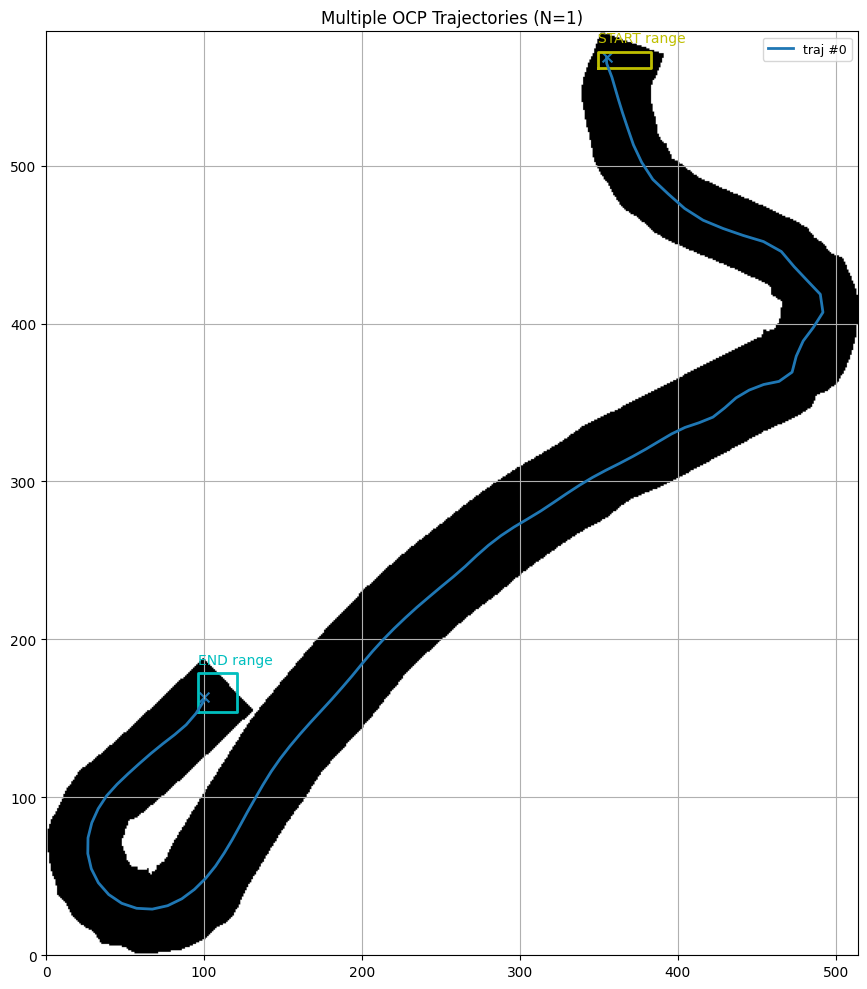

In [22]:
# %% [Batch generate multiple randomized trajectories, report start/end deltas]
import numpy as np
import matplotlib.pyplot as plt

# ====== 0) Config ======
N_TRAJ = 1              # 生成多少条轨迹
SEED = None             # 例如 42；None 则每次不同
PLOT_EACH = False       # 是否为每条轨迹单独画控件/速度子图（用你已有的 plot_results）

# 起点/终点的取值范围（对角点）
START_A = np.array([349.3, 572.1])
START_B = np.array([382.7, 561.9])
END_A   = np.array([120.70, 153.80])
END_B   = np.array([95.90,  178.50])

# 若上一段没定义 w_safety_schedule，这里兜底
try:
    _ = w_safety_schedule
except NameError:
    w_safety_schedule = [100.0, 800.0, 3200.0, 12800.0, 51200.0]

rng = np.random.default_rng(SEED)

# ====== 1) Helpers ======
def sample_in_box(P, Q, rng):
    lo = np.minimum(P, Q); hi = np.maximum(P, Q)
    return rng.uniform(lo, hi)

def nearest_index(points, target_xy):
    d2 = np.sum((points - target_xy[None, :])**2, axis=1)
    return int(np.argmin(d2))

def resample_polyline_to_N(pts, N):
    s = np.concatenate(([0.0], np.cumsum(np.linalg.norm(np.diff(pts, axis=0), axis=1))))
    fx = interp1d(s, pts[:, 0], kind='cubic')
    fy = interp1d(s, pts[:, 1], kind='cubic')
    s_new = np.linspace(0.0, s[-1], N)
    return np.vstack([fx(s_new), fy(s_new)]).T, s[-1]

def draw_box(ax, P, Q, label, color='y'):
    lo = np.minimum(P, Q); hi = np.maximum(P, Q)
    xs = [lo[0], hi[0], hi[0], lo[0], lo[0]]
    ys = [lo[1], lo[1], hi[1], hi[1], lo[1]]
    ax.plot(xs, ys, color=color, lw=2)
    ax.text(lo[0], hi[1] + 6, label, color=color)

# ====== 2) Batch run ======
results = []  # 收集信息以打印汇总
colors = plt.cm.get_cmap('tab10', N_TRAJ)

for i in range(N_TRAJ):
    # --- 随机采样起终点 ---
    start_sample = sample_in_box(START_A, START_B, rng)
    end_sample   = sample_in_box(END_A,   END_B,   rng)

    # --- 在全局 raceline 上取子段并重采样 ---
    idx_s = nearest_index(raceline_grid, start_sample)
    idx_e = nearest_index(raceline_grid, end_sample)
    if idx_s == idx_e:
        idx_e = min(idx_s + 1, len(raceline_grid) - 1)

    if idx_s < idx_e:
        sub_poly = raceline_grid[idx_s:idx_e + 1]
    else:
        sub_poly = raceline_grid[idx_e:idx_s + 1][::-1]

    raceline_ref_seg, seg_len_px = resample_polyline_to_N(sub_poly, state_steps)
    # 终点“强吸引”：参考末点替换为采样的终点
    raceline_ref_seg[-1] = end_sample

    # --- 参考朝向、速度（与主流程一致，但基于子段长度） ---
    dxy_seg = np.diff(raceline_ref_seg, axis=0, append=raceline_ref_seg[-1:])
    theta_ref_seg = np.arctan2(dxy_seg[:, 1], dxy_seg[:, 0])

    total_time_seg = control_steps * dt
    avg_speed_pix_seg = seg_len_px / (total_time_seg + 1e-12)
    v_max_seg = 3.5 * avg_speed_pix_seg
    v_ref_seg = np.clip(np.linspace(0, 2.0 * avg_speed_pix_seg, state_steps), 0, v_max_seg)

    # --- 初始状态：起点锁死，朝向取子段切向，初速 0 ---
    theta0_seg = np.arctan2(raceline_ref_seg[1, 1] - raceline_ref_seg[0, 1],
                            raceline_ref_seg[1, 0] - raceline_ref_seg[0, 0])
    x0_seg = np.array([start_sample[0], start_sample[1], theta0_seg, 0.0])

    # --- 续接法求解（完全复用你的 OCP 配置） ---
    z_init = np.zeros(control_steps * 2)
    for w_s in w_safety_schedule:
        res_seg = minimize(
            cost_function_reparam,
            z_init,
            args=(x0_seg, raceline_ref_seg, theta_ref_seg, v_ref_seg, dt,
                  state_steps, control_steps, a_max, delta_max, 2.7 * resolution, v_max_seg,
                  sdf_map, safety_margin_pix, w_s),
            method="L-BFGS-B",
            options={"maxiter": 400, "maxfun": 200000, "ftol": 1e-6, "gtol": 1e-5, "maxls": 50, "disp": False}
        )
        z_init = res_seg.x

    # --- 回放 ---
    u_opt_seg = unpack_controls(res_seg.x, control_steps, a_max, delta_max)
    states_opt_seg = simulate_vehicle_bc(x0_seg, u_opt_seg, dt, state_steps,
                                         L_pix=2.7 * resolution, v_max=v_max_seg)

    # --- 距离差异（像素 & 米） ---
    start_real = states_opt_seg[0, :2]
    end_real   = states_opt_seg[-1, :2]
    d_start_px = float(np.linalg.norm(start_real - start_sample))
    d_end_px   = float(np.linalg.norm(end_real - end_sample))
    d_start_m  = (d_start_px / resolution) if (resolution and resolution > 0) else np.nan
    d_end_m    = (d_end_px   / resolution) if (resolution and resolution > 0) else np.nan

    results.append({
        "i": i,
        "start_sample": start_sample, "end_sample": end_sample,
        "start_real": start_real, "end_real": end_real,
        "d_start_px": d_start_px, "d_end_px": d_end_px,
        "d_start_m": d_start_m, "d_end_m": d_end_m,
        "states": states_opt_seg, "u": u_opt_seg, "v_max_seg": v_max_seg,
        "raceline_ref_seg": raceline_ref_seg
    })

    # 可选：逐条画控件/速度（使用你之前的 plot_results；其内部用到全局 v_max，这里同步）
    if PLOT_EACH:
        v_max = v_max_seg
        plot_results(states_opt_seg, u_opt_seg, raceline_ref_seg, v_ref_seg,
                     grid_map, dt, control_steps, a_max, delta_max)

# ====== 3) 汇总打印 ======
print("\n=== Trajectory summary (deltas: realized vs planned) ===")
for r in results:
    i = r["i"]
    ss, es = r["start_sample"], r["end_sample"]
    sr, er = r["start_real"], r["end_real"]
    print(f"[#{i:02d}] "
          f"start planned=({ss[0]:.2f},{ss[1]:.2f})  realized=({sr[0]:.2f},{sr[1]:.2f})  "
          f"Δstart = {r['d_start_px']:.3f} px ({r['d_start_m']:.3f} m) | "
          f"end planned=({es[0]:.2f},{es[1]:.2f})  realized=({er[0]:.2f},{er[1]:.2f})  "
          f"Δend = {r['d_end_px']:.3f} px ({r['d_end_m']:.3f} m)")

avg_end_px = np.mean([r["d_end_px"] for r in results])
avg_end_m  = np.mean([r["d_end_m"]  for r in results if not np.isnan(r["d_end_m"])]) if len(results)>0 else np.nan
print(f"\nAverage Δend: {avg_end_px:.3f} px ({avg_end_m:.3f} m) over {len(results)} runs.")

# ====== 4) 轨迹总览可视化（同一张图） ======
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(grid_map, cmap='gray', origin='lower',
          extent=[0, grid_map.shape[1], 0, grid_map.shape[0]])
draw_box(ax, START_A, START_B, 'START range', color='y')
draw_box(ax, END_A,   END_B,   'END range',   color='c')

for r in results:
    i = r["i"]
    col = colors(i)
    st = r["states"]
    ax.plot(st[:, 0], st[:, 1], '-', lw=2.0, color=col, label=f'traj #{i}')
    ax.scatter([r["start_sample"][0], r["end_sample"][0]],
               [r["start_sample"][1], r["end_sample"][1]],
               s=50, marker='x', color=col)

ax.set_aspect('equal', adjustable='box')
ax.grid(True)
ax.set_title(f'Multiple OCP Trajectories (N={N_TRAJ})')
ax.legend(loc='best', fontsize=9, ncol=2)
plt.tight_layout()
plt.show()


In [23]:
# # FAST
# # %% [Batch generate multiple randomized trajectories, report start/end deltas]
# import numpy as np
# import matplotlib.pyplot as plt

# # ====== 0) Config ======
# N_TRAJ = 5              # 生成多少条轨迹
# SEED = None             # 例如 42；None 则每次不同
# PLOT_EACH = False       # 是否为每条轨迹单独画控件/速度子图（用你已有的 plot_results）

# # 起点/终点的取值范围（对角点）
# START_A = np.array([349.3, 572.1])
# START_B = np.array([382.7, 561.9])
# END_A   = np.array([120.70, 153.80])
# END_B   = np.array([95.90,  178.50])

# # 若上一段没定义 w_safety_schedule，这里兜底
# try:
#     _ = w_safety_schedule
# except NameError:
    
#     w_safety_schedule = [1200.0, 24000.0, 96000.0] 

# rng = np.random.default_rng(SEED)   

# # ====== 1) Helpers ======
# def sample_in_box(P, Q, rng):
#     lo = np.minimum(P, Q); hi = np.maximum(P, Q)
#     return rng.uniform(lo, hi)

# def nearest_index(points, target_xy):
#     d2 = np.sum((points - target_xy[None, :])**2, axis=1)
#     return int(np.argmin(d2))

# def resample_polyline_to_N(pts, N):
#     s = np.concatenate(([0.0], np.cumsum(np.linalg.norm(np.diff(pts, axis=0), axis=1))))
#     fx = interp1d(s, pts[:, 0], kind='cubic')
#     fy = interp1d(s, pts[:, 1], kind='cubic')
#     s_new = np.linspace(0.0, s[-1], N)
#     return np.vstack([fx(s_new), fy(s_new)]).T, s[-1]

# def draw_box(ax, P, Q, label, color='y'):
#     lo = np.minimum(P, Q); hi = np.maximum(P, Q)
#     xs = [lo[0], hi[0], hi[0], lo[0], lo[0]]
#     ys = [lo[1], lo[1], hi[1], hi[1], lo[1]]
#     ax.plot(xs, ys, color=color, lw=2)
#     ax.text(lo[0], hi[1] + 6, label, color=color)

# # ====== 2) Batch run ======
# results = []  # 收集信息以打印汇总
# colors = plt.cm.get_cmap('tab10', N_TRAJ)

# for i in range(N_TRAJ):
#     # --- 随机采样起终点 ---
#     start_sample = sample_in_box(START_A, START_B, rng)
#     end_sample   = sample_in_box(END_A,   END_B,   rng)

#     # --- 在全局 raceline 上取子段并重采样 ---
#     idx_s = nearest_index(raceline_grid, start_sample)
#     idx_e = nearest_index(raceline_grid, end_sample)
#     if idx_s == idx_e:
#         idx_e = min(idx_s + 1, len(raceline_grid) - 1)

#     if idx_s < idx_e:
#         sub_poly = raceline_grid[idx_s:idx_e + 1]
#     else:
#         sub_poly = raceline_grid[idx_e:idx_s + 1][::-1]

#     raceline_ref_seg, seg_len_px = resample_polyline_to_N(sub_poly, state_steps)
#     # 终点“强吸引”：参考末点替换为采样的终点
#     raceline_ref_seg[-1] = end_sample

#     # --- 参考朝向、速度（与主流程一致，但基于子段长度） ---
#     dxy_seg = np.diff(raceline_ref_seg, axis=0, append=raceline_ref_seg[-1:])
#     theta_ref_seg = np.arctan2(dxy_seg[:, 1], dxy_seg[:, 0])

#     total_time_seg = control_steps * dt
#     avg_speed_pix_seg = seg_len_px / (total_time_seg + 1e-12)
#     v_max_seg = 3.5 * avg_speed_pix_seg
#     v_ref_seg = np.clip(np.linspace(0, 2.0 * avg_speed_pix_seg, state_steps), 0, v_max_seg)

#     # --- 初始状态：起点锁死，朝向取子段切向，初速 0 ---
#     theta0_seg = np.arctan2(raceline_ref_seg[1, 1] - raceline_ref_seg[0, 1],
#                             raceline_ref_seg[1, 0] - raceline_ref_seg[0, 0])
#     x0_seg = np.array([start_sample[0], start_sample[1], theta0_seg, 0.0])

#     # --- 续接法求解（完全复用你的 OCP 配置） ---
#     z_init = np.zeros(control_steps * 2)
#     for w_s in w_safety_schedule:
#         res_seg = minimize(
#             cost_function_reparam,
#             z_init,
#             args=(x0_seg, raceline_ref_seg, theta_ref_seg, v_ref_seg, dt,
#                   state_steps, control_steps, a_max, delta_max, 2.7 * resolution, v_max_seg,
#                   sdf_map, safety_margin_pix, w_s),
#             method="L-BFGS-B",
#             options={"maxiter": 220, "maxfun": 60000, "ftol": 1e-5, "gtol": 2e-4, "maxls": 25, "disp": False}
#         )
#         z_init = res_seg.x

#     # --- 回放 ---
#     u_opt_seg = unpack_controls(res_seg.x, control_steps, a_max, delta_max)
#     states_opt_seg = simulate_vehicle_bc(x0_seg, u_opt_seg, dt, state_steps,
#                                          L_pix=2.7 * resolution, v_max=v_max_seg)

#     # --- 距离差异（像素 & 米） ---
#     start_real = states_opt_seg[0, :2]
#     end_real   = states_opt_seg[-1, :2]
#     d_start_px = float(np.linalg.norm(start_real - start_sample))
#     d_end_px   = float(np.linalg.norm(end_real - end_sample))
#     d_start_m  = (d_start_px / resolution) if (resolution and resolution > 0) else np.nan
#     d_end_m    = (d_end_px   / resolution) if (resolution and resolution > 0) else np.nan

#     results.append({
#         "i": i,
#         "start_sample": start_sample, "end_sample": end_sample,
#         "start_real": start_real, "end_real": end_real,
#         "d_start_px": d_start_px, "d_end_px": d_end_px,
#         "d_start_m": d_start_m, "d_end_m": d_end_m,
#         "states": states_opt_seg, "u": u_opt_seg, "v_max_seg": v_max_seg,
#         "raceline_ref_seg": raceline_ref_seg
#     })

#     # 可选：逐条画控件/速度（使用你之前的 plot_results；其内部用到全局 v_max，这里同步）
#     if PLOT_EACH:
#         v_max = v_max_seg
#         plot_results(states_opt_seg, u_opt_seg, raceline_ref_seg, v_ref_seg,
#                      grid_map, dt, control_steps, a_max, delta_max)

# # ====== 3) 汇总打印 ======
# print("\n=== Trajectory summary (deltas: realized vs planned) ===")
# for r in results:
#     i = r["i"]
#     ss, es = r["start_sample"], r["end_sample"]
#     sr, er = r["start_real"], r["end_real"]
#     print(f"[#{i:02d}] "
#           f"start planned=({ss[0]:.2f},{ss[1]:.2f})  realized=({sr[0]:.2f},{sr[1]:.2f})  "
#           f"Δstart = {r['d_start_px']:.3f} px ({r['d_start_m']:.3f} m) | "
#           f"end planned=({es[0]:.2f},{es[1]:.2f})  realized=({er[0]:.2f},{er[1]:.2f})  "
#           f"Δend = {r['d_end_px']:.3f} px ({r['d_end_m']:.3f} m)")

# avg_end_px = np.mean([r["d_end_px"] for r in results])
# avg_end_m  = np.mean([r["d_end_m"]  for r in results if not np.isnan(r["d_end_m"])]) if len(results)>0 else np.nan
# print(f"\nAverage Δend: {avg_end_px:.3f} px ({avg_end_m:.3f} m) over {len(results)} runs.")

# # ====== 4) 轨迹总览可视化（同一张图） ======
# fig, ax = plt.subplots(figsize=(10, 10))
# ax.imshow(grid_map, cmap='gray', origin='lower',
#           extent=[0, grid_map.shape[1], 0, grid_map.shape[0]])
# draw_box(ax, START_A, START_B, 'START range', color='y')
# draw_box(ax, END_A,   END_B,   'END range',   color='c')

# for r in results:
#     i = r["i"]
#     col = colors(i)
#     st = r["states"]
#     ax.plot(st[:, 0], st[:, 1], '-', lw=2.0, color=col, label=f'traj #{i}')
#     ax.scatter([r["start_sample"][0], r["end_sample"][0]],
#                [r["start_sample"][1], r["end_sample"][1]],
#                s=50, marker='x', color=col)

# ax.set_aspect('equal', adjustable='box')
# ax.grid(True)
# ax.set_title(f'Multiple OCP Trajectories (N={N_TRAJ})')
# ax.legend(loc='best', fontsize=9, ncol=2)
# plt.tight_layout()
# plt.show()



In [24]:
# PARALLEL OCP DATASET (incremental saving every CHUNK trajs)
# %% [Max-CPU generation with periodic NPZ saves: states, actions, init conditions]
import os, json, time
import numpy as np
from concurrent.futures import ProcessPoolExecutor, as_completed

# ============ CONFIG ============
TOTAL_TRAJ = 2000                 # 总共要生成多少条
CHUNK = 10                       # 每得到多少条就保存一次
SAVE_PATH = "./outputs/ocp_dataset_incremental.npz"
os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)

CPU_WORKERS = os.cpu_count()     # 最大化利用 CPU（如需留余量可改小）
SEED = None                      # 固定种子可复现；None 则每次不同
rng_master = np.random.default_rng(SEED)

# 限制底层BLAS多线程，避免过度超订阅（子进程继承）
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

# L-BFGS-B 选项（沿用你当前的“加速但稳”配置）
LBFGS_OPTS = {"maxiter": 220, "maxfun": 60000, "ftol": 1e-5, "gtol": 2e-4, "maxls": 25, "disp": False}

# ============ WORKER ============
def _solve_one_job(job_seed):
    """
    单条轨迹求解：随机起终点 -> 子段参考 -> OCP（续接） -> rollout
    返回 dict（小而齐全），便于序列化存盘
    依赖：本 cell 之前已定义的函数/变量：minimize, cost_function_reparam, simulate_vehicle_bc,
          unpack_controls, resample_polyline_to_N, nearest_index, sample_in_box 等
    """
    # 独立 RNG
    rng = np.random.default_rng(job_seed)

    # 1) 采样起终点（沿用当前范围）
    start_sample = sample_in_box(START_A, START_B, rng)
    end_sample   = sample_in_box(END_A,   END_B,   rng)

    # 2) 在 raceline 上取子段并重采样参考
    idx_s = nearest_index(raceline_grid, start_sample)
    idx_e = nearest_index(raceline_grid, end_sample)
    if idx_s == idx_e:
        idx_e = min(idx_s + 1, len(raceline_grid) - 1)
    sub_poly = raceline_grid[idx_s:idx_e + 1] if idx_s < idx_e else raceline_grid[idx_e:idx_s + 1][::-1]

    raceline_ref_seg, seg_len_px = resample_polyline_to_N(sub_poly, state_steps)
    raceline_ref_seg[-1] = end_sample  # 终点强吸引

    dxy_seg = np.diff(raceline_ref_seg, axis=0, append=raceline_ref_seg[-1:])
    theta_ref_seg = np.arctan2(dxy_seg[:, 1], dxy_seg[:, 0])

    total_time_seg = control_steps * dt
    avg_speed_pix_seg = seg_len_px / (total_time_seg + 1e-12)
    v_max_seg = 3.5 * avg_speed_pix_seg
    v_ref_seg = np.clip(np.linspace(0, 2.0 * avg_speed_pix_seg, state_steps), 0, v_max_seg)

    # 3) 初始状态
    theta0_seg = np.arctan2(raceline_ref_seg[1, 1] - raceline_ref_seg[0, 1],
                            raceline_ref_seg[1, 0] - raceline_ref_seg[0, 0])
    x0_seg = np.array([start_sample[0], start_sample[1], theta0_seg, 0.0], dtype=np.float64)

    # 4) OCP 续接求解
    z_init = np.zeros(control_steps * 2, dtype=np.float64)
    for w_s in w_safety_schedule:
        res_seg = minimize(
            cost_function_reparam,
            z_init,
            args=(x0_seg, raceline_ref_seg, theta_ref_seg, v_ref_seg, dt,
                  state_steps, control_steps, a_max, delta_max, 2.7 * resolution, v_max_seg,
                  sdf_map, safety_margin_pix, w_s),
            method="L-BFGS-B",
            options=LBFGS_OPTS
        )
        z_init = res_seg.x  # warm start

    # 5) 回放
    u_opt = unpack_controls(res_seg.x, control_steps, a_max, delta_max).astype(np.float64)
    states_opt = simulate_vehicle_bc(x0_seg, u_opt, dt, state_steps,
                                     L_pix=2.7 * resolution, v_max=v_max_seg).astype(np.float64)

    # 6) 返回可直接堆叠/保存的结果
    return dict(
        actions=u_opt,                          # [T,2]
        states=states_opt,                      # [T+1,4] (即 state_steps×4)
        x0=x0_seg,                              # [4]
        start=start_sample.astype(np.float64),  # [2]
        end=end_sample.astype(np.float64),      # [2]
        raceline_ref=raceline_ref_seg.astype(np.float64),  # [state_steps,2]
        v_max_seg=float(v_max_seg)
    )

# ============ SAVE ============
def _save_npz(path, buf):
    """
    buf: list of dict（每条轨迹），将其堆叠并写入 NPZ（压缩）
    """
    if not buf:
        return
    actions = np.stack([b["actions"] for b in buf], axis=0)         # [N,T,2]
    states  = np.stack([b["states"]  for b in buf], axis=0)         # [N,state_steps,4]
    x0s     = np.stack([b["x0"]      for b in buf], axis=0)         # [N,4]
    starts  = np.stack([b["start"]   for b in buf], axis=0)         # [N,2]
    ends    = np.stack([b["end"]     for b in buf], axis=0)         # [N,2]
    refs    = np.stack([b["raceline_ref"] for b in buf], axis=0)    # [N,state_steps,2]
    vmaxs   = np.array([b["v_max_seg"] for b in buf], dtype=np.float64)

    # 若已存在旧文件，先读出再拼接，实现“增量存储”
    if os.path.isfile(path):
        old = np.load(path, allow_pickle=False)
        actions = np.concatenate([old["actions"], actions], axis=0)
        states  = np.concatenate([old["states"],  states],  axis=0)
        x0s     = np.concatenate([old["x0s"],     x0s],     axis=0)
        starts  = np.concatenate([old["starts"],   starts],  axis=0)
        ends    = np.concatenate([old["ends"],     ends],    axis=0)
        refs    = np.concatenate([old["refs"],     refs],    axis=0)
        vmaxs   = np.concatenate([old["vmaxs"],    vmaxs],   axis=0)

    np.savez_compressed(
        path,
        actions=actions,
        states=states,
        x0s=x0s,
        starts=starts,
        ends=ends,
        refs=refs,
        vmaxs=vmaxs,
        # 元数据（便于复现）
        dt=np.float64(dt),
        state_steps=np.int64(state_steps),
        control_steps=np.int64(control_steps),
        a_max=np.float64(a_max),
        delta_max=np.float64(delta_max),
        resolution=np.float64(resolution),
        safety_margin_pix=np.float64(safety_margin_pix)
    )

# ============ DISPATCH ============
t0 = time.time()
produced_total = 0
buffer = []  # 暂存本轮新增（未写盘）结果

print(f"[Start] target={TOTAL_TRAJ}, chunk={CHUNK}, workers={CPU_WORKERS}")
with ProcessPoolExecutor(max_workers=CPU_WORKERS) as ex:
    # 预派发第一批
    in_flight = {}
    submit_n = min(TOTAL_TRAJ, CPU_WORKERS * 2)  # 先发两倍worker的任务填满管道
    for _ in range(submit_n):
        fut = ex.submit(_solve_one_job, int(rng_master.integers(0, 2**31-1)))
        in_flight[fut] = True

    while produced_total < TOTAL_TRAJ:
        # 等一条完成
        done_fut = next(as_completed(in_flight))
        in_flight.pop(done_fut, None)
        try:
            res = done_fut.result()
            buffer.append(res)
            produced_total += 1
            # 动态补一个新任务，保持管道充盈
            remaining = TOTAL_TRAJ - (len(in_flight) + produced_total)
            if remaining > 0:
                fut = ex.submit(_solve_one_job, int(rng_master.integers(0, 2**31-1)))
                in_flight[fut] = True
        except Exception as e:
            print(f"[warn] one job failed: {e!r}")

        # 到达 CHUNK 条就存盘
        if len(buffer) >= CHUNK or (produced_total == TOTAL_TRAJ):
            _save_npz(SAVE_PATH, buffer)
            print(f"[save] total={produced_total}/{TOTAL_TRAJ}  file={SAVE_PATH}  (+{len(buffer)} just saved)")
            buffer = []

t1 = time.time()
print(f"[Done] generated {produced_total} trajs in {t1 - t0:.1f}s -> {SAVE_PATH}")

# 可选：快速检查（不绘图，读回形状）
check = np.load(SAVE_PATH)
print("NPZ keys:", list(check.keys()))
print("actions:", check["actions"].shape, "states:", check["states"].shape, "refs:", check["refs"].shape)


[Start] target=2000, chunk=10, workers=32
[save] total=10/2000  file=./outputs/ocp_dataset_incremental.npz  (+10 just saved)
[save] total=20/2000  file=./outputs/ocp_dataset_incremental.npz  (+10 just saved)
[save] total=30/2000  file=./outputs/ocp_dataset_incremental.npz  (+10 just saved)
[save] total=40/2000  file=./outputs/ocp_dataset_incremental.npz  (+10 just saved)
[save] total=50/2000  file=./outputs/ocp_dataset_incremental.npz  (+10 just saved)
[save] total=60/2000  file=./outputs/ocp_dataset_incremental.npz  (+10 just saved)
[save] total=70/2000  file=./outputs/ocp_dataset_incremental.npz  (+10 just saved)
[save] total=80/2000  file=./outputs/ocp_dataset_incremental.npz  (+10 just saved)
[save] total=90/2000  file=./outputs/ocp_dataset_incremental.npz  (+10 just saved)
[save] total=100/2000  file=./outputs/ocp_dataset_incremental.npz  (+10 just saved)
[save] total=110/2000  file=./outputs/ocp_dataset_incremental.npz  (+10 just saved)
[save] total=120/2000  file=./outputs/ocp_d

In [25]:
# %% [数据验证：检查生成数据集的形状和基本统计信息]
import numpy as np
import matplotlib.pyplot as plt

# 加载数据集
data_path = "./outputs/ocp_dataset_incremental.npz"
data = np.load(data_path, allow_pickle=False)

print("=== 数据集基本信息 ===")
print(f"数据集路径: {data_path}")
print(f"数据文件大小: {os.path.getsize(data_path) / (1024*1024):.2f} MB")
print()

print("=== NPZ 文件包含的键 ===")
for key in data.keys():
    print(f"- {key}")
print()

print("=== 主要数据数组形状 ===")
print(f"actions (控制输入):  {data['actions'].shape}")
print(f"states (状态轨迹):   {data['states'].shape}")  
print(f"x0s (初始状态):      {data['x0s'].shape}")
print(f"starts (起点):       {data['starts'].shape}")
print(f"ends (终点):         {data['ends'].shape}")
print(f"refs (参考轨迹):     {data['refs'].shape}")
print(f"vmaxs (最大速度):    {data['vmaxs'].shape}")
print()

print("=== 元数据参数 ===")
metadata_keys = ['dt', 'state_steps', 'control_steps', 'a_max', 'delta_max', 
                 'resolution', 'safety_margin_pix']
for key in metadata_keys:
    if key in data:
        print(f"{key}: {data[key]}")
print()

print("=== 数据维度验证 ===")
n_trajs = data['actions'].shape[0]
control_steps = data['control_steps'].item() if 'control_steps' in data else data['actions'].shape[1]
state_steps = data['state_steps'].item() if 'state_steps' in data else data['states'].shape[1]

print(f"轨迹数量: {n_trajs}")
print(f"控制步数: {control_steps} (actions的时间维度)")
print(f"状态步数: {state_steps} (states的时间维度)")
print(f"预期关系: state_steps = control_steps + 1 -> {state_steps} = {control_steps} + 1 ✓" 
      if state_steps == control_steps + 1 else 
      f"预期关系: state_steps = control_steps + 1 -> {state_steps} ≠ {control_steps} + 1 ✗")
print()

print("=== 数据范围统计 ===")
print("Actions (加速度, 转向角):")
print(f"  形状: {data['actions'].shape}")
print(f"  范围: [{data['actions'].min():.4f}, {data['actions'].max():.4f}]")
print(f"  均值: {data['actions'].mean(axis=(0,1))}")
print(f"  标准差: {data['actions'].std(axis=(0,1))}")
print()

print("States (x, y, theta, v):")
print(f"  形状: {data['states'].shape}")
print(f"  位置 (x,y) 范围: x[{data['states'][:,:,0].min():.2f}, {data['states'][:,:,0].max():.2f}], y[{data['states'][:,:,1].min():.2f}, {data['states'][:,:,1].max():.2f}]")
print(f"  角度 theta 范围: [{data['states'][:,:,2].min():.4f}, {data['states'][:,:,2].max():.4f}]")
print(f"  速度 v 范围: [{data['states'][:,:,3].min():.4f}, {data['states'][:,:,3].max():.4f}]")
print()

print("起终点:")
print(f"  起点范围: x[{data['starts'][:,0].min():.2f}, {data['starts'][:,0].max():.2f}], y[{data['starts'][:,1].min():.2f}, {data['starts'][:,1].max():.2f}]")
print(f"  终点范围: x[{data['ends'][:,0].min():.2f}, {data['ends'][:,0].max():.2f}], y[{data['ends'][:,1].min():.2f}, {data['ends'][:,1].max():.2f}]")
print()

print("最大速度:")
print(f"  v_max 范围: [{data['vmaxs'].min():.4f}, {data['vmaxs'].max():.4f}]")
print(f"  v_max 均值: {data['vmaxs'].mean():.4f}")
print()

# 检查数据一致性
print("=== 数据一致性检查 ===")
# 检查初始状态是否与状态轨迹第一步一致
init_state_match = np.allclose(data['x0s'], data['states'][:,0], atol=1e-6)
print(f"初始状态一致性: {'✓' if init_state_match else '✗'}")

# 检查起点是否与状态轨迹第一步的位置一致
start_pos_match = np.allclose(data['starts'], data['states'][:,0,:2], atol=1e-6)
print(f"起点位置一致性: {'✓' if start_pos_match else '✗'}")

# 抽样检查几条轨迹
print()
print("=== 样本轨迹预览 ===")
for i in [0, n_trajs//2, n_trajs-1]:
    print(f"轨迹 {i}:")
    print(f"  起点: ({data['starts'][i,0]:.3f}, {data['starts'][i,1]:.3f})")
    print(f"  终点: ({data['ends'][i,0]:.3f}, {data['ends'][i,1]:.3f})")
    print(f"  初始状态: x={data['x0s'][i,0]:.3f}, y={data['x0s'][i,1]:.3f}, θ={data['x0s'][i,2]:.3f}, v={data['x0s'][i,3]:.3f}")
    print(f"  最终状态: x={data['states'][i,-1,0]:.3f}, y={data['states'][i,-1,1]:.3f}, θ={data['states'][i,-1,2]:.3f}, v={data['states'][i,-1,3]:.3f}")
    print(f"  轨迹长度: {np.linalg.norm(data['states'][i,-1,:2] - data['states'][i,0,:2]):.3f}")
    print(f"  v_max: {data['vmaxs'][i]:.3f}")
    print()

data.close()
print("数据验证完成!")

=== 数据集基本信息 ===
数据集路径: ./outputs/ocp_dataset_incremental.npz
数据文件大小: 9.56 MB

=== NPZ 文件包含的键 ===
- actions
- states
- x0s
- starts
- ends
- refs
- vmaxs
- dt
- state_steps
- control_steps
- a_max
- delta_max
- resolution
- safety_margin_pix

=== 主要数据数组形状 ===
actions (控制输入):  (2010, 100, 2)
states (状态轨迹):   (2010, 101, 4)
x0s (初始状态):      (2010, 4)
starts (起点):       (2010, 2)
ends (终点):         (2010, 2)
refs (参考轨迹):     (2010, 101, 2)
vmaxs (最大速度):    (2010,)

=== 元数据参数 ===
dt: 0.2
state_steps: 101
control_steps: 100
a_max: 35.0
delta_max: 1.0
resolution: 1.0
safety_margin_pix: 10.0

=== 数据维度验证 ===
轨迹数量: 2010
控制步数: 100 (actions的时间维度)
状态步数: 101 (states的时间维度)
预期关系: state_steps = control_steps + 1 -> 101 = 100 + 1 ✓

=== 数据范围统计 ===
Actions (加速度, 转向角):
  形状: (2010, 100, 2)
  范围: [-7.8897, 33.1011]
  均值: [ 2.45024335 -0.00707589]
  标准差: [8.82640157 0.04795298]

States (x, y, theta, v):
  形状: (2010, 101, 4)
  位置 (x,y) 范围: x[18.41, 514.03], y[-18.53, 572.10]
  角度 theta 范围: [-6.4612, 0.0447]


Loaded dataset: 2010 trajectories
Loaded track map: (585, 514)
Selected trajectory indices: [np.int64(124), np.int64(393), np.int64(429), np.int64(433), np.int64(462), np.int64(526), np.int64(530), np.int64(561), np.int64(576), np.int64(611), np.int64(651), np.int64(710), np.int64(812), np.int64(1196), np.int64(1211), np.int64(1404), np.int64(1450), np.int64(1473), np.int64(1505), np.int64(1770)]


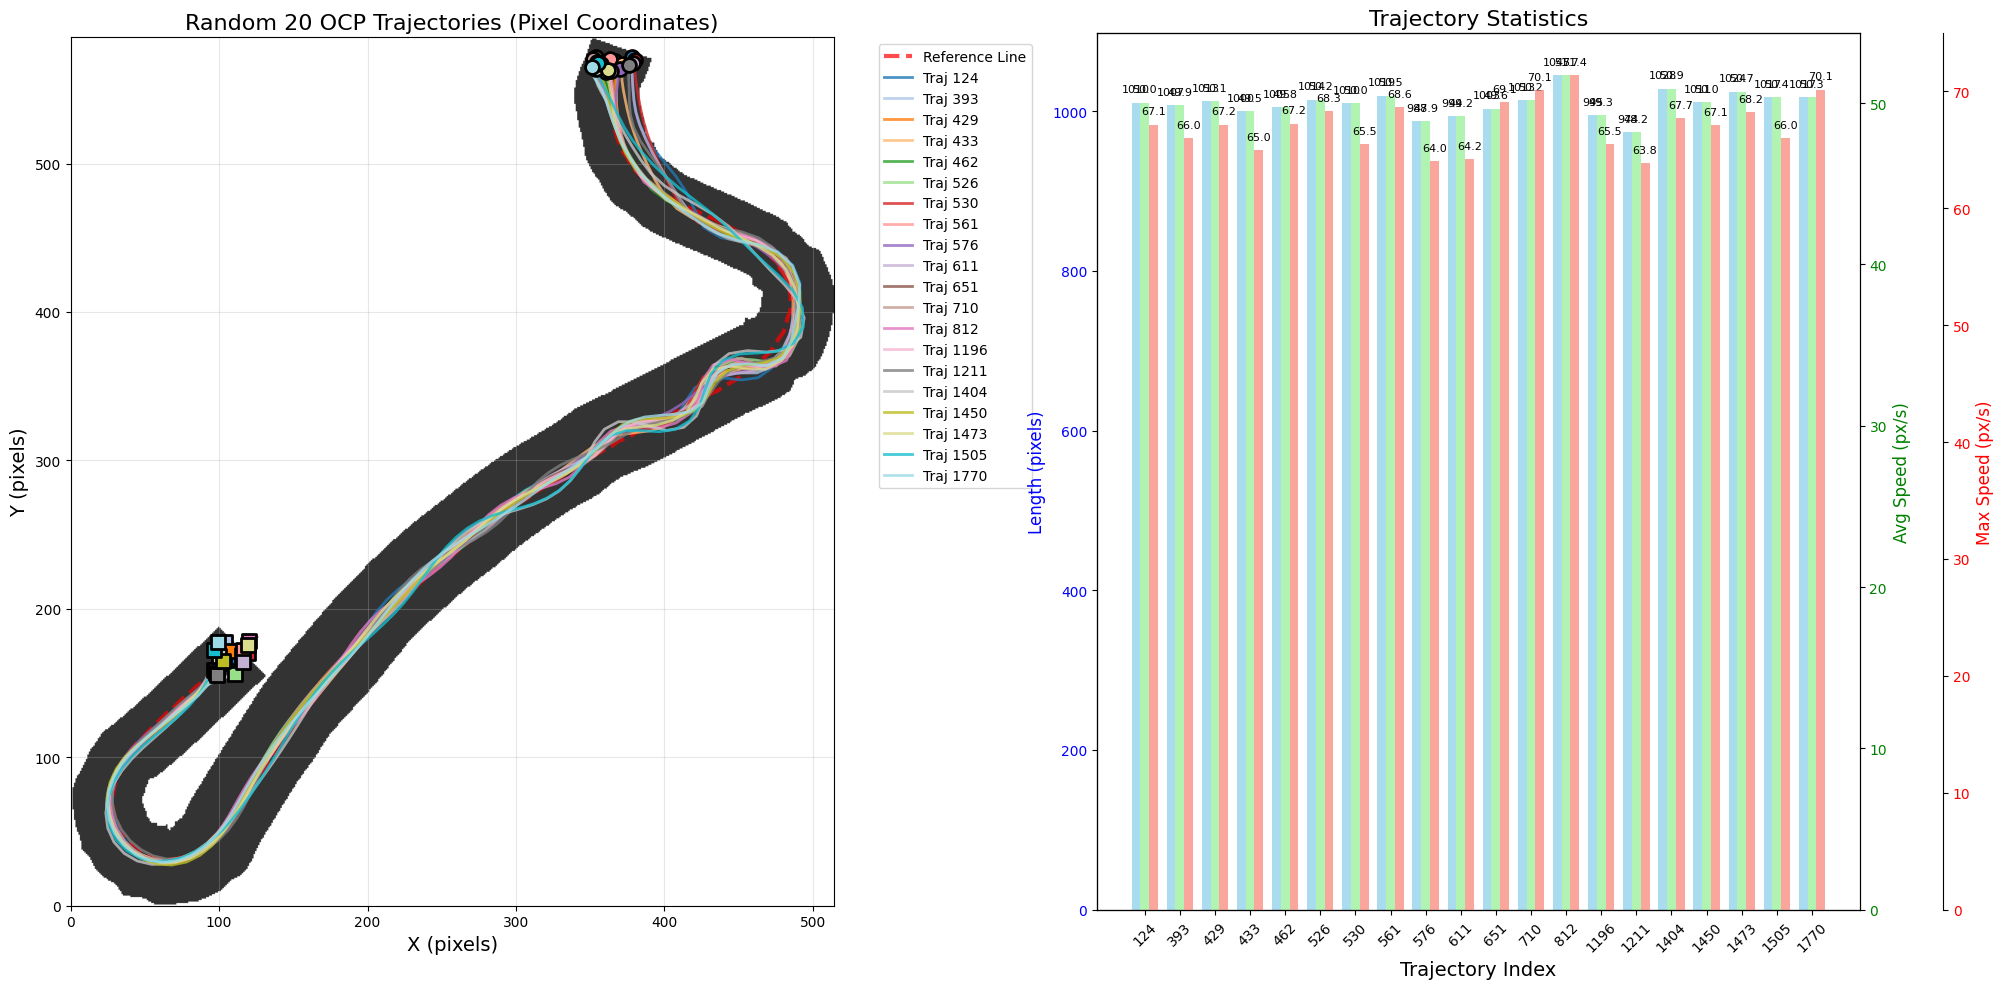


=== Selected Trajectory Details ===
Traj  124: Start( 378.0,  571.5) -> End( 112.7,  167.8), Length=1010.5, Avg Speed=50.02, Max Speed=67.15, v_max=173.70
Traj  393: Start( 368.2,  565.5) -> End( 103.8,  177.7), Length=1007.5, Avg Speed=49.87, Max Speed=66.02, v_max=174.58
Traj  429: Start( 366.7,  569.2) -> End( 106.4,  171.9), Length=1012.8, Avg Speed=50.14, Max Speed=67.15, v_max=173.70
Traj  433: Start( 371.8,  567.4) -> End( 115.2,  169.2), Length= 999.9, Avg Speed=49.50, Max Speed=64.98, v_max=174.58
Traj  462: Start( 360.9,  561.9) -> End( 101.1,  163.5), Length=1005.2, Avg Speed=49.76, Max Speed=67.24, v_max=171.06
Traj  526: Start( 353.3,  564.3) -> End( 110.7,  156.2), Length=1014.4, Avg Speed=50.22, Max Speed=68.30, v_max=171.06
Traj  530: Start( 380.4,  569.9) -> End( 119.4,  170.4), Length=1010.1, Avg Speed=50.01, Max Speed=65.49, v_max=175.45
Traj  561: Start( 363.4,  570.4) -> End( 116.1,  172.1), Length=1019.4, Avg Speed=50.47, Max Speed=68.64, v_max=174.58
Traj  576: 

In [30]:
# %% [Visualization: Randomly sample 20 trajectories from dataset and display on track map]
import numpy as np
import matplotlib.pyplot as plt
import os

# Load OCP dataset
data_path = "./outputs/ocp_dataset_incremental.npz"
data = np.load(data_path, allow_pickle=False)

print(f"Loaded dataset: {data['actions'].shape[0]} trajectories")

# Load track map
map_path = "nuerburgring_segment_map.npz"
if os.path.exists(map_path):
    map_data = np.load(map_path, allow_pickle=False)
    grid_map = map_data['grid_map']
    raceline_grid = map_data['raceline_grid']
    print(f"Loaded track map: {grid_map.shape}")
else:
    print(f"Warning: Map file {map_path} not found, creating blank map")
    # Infer map size from trajectory data
    all_states = data['states']
    x_max, y_max = all_states[:,:,:2].max(axis=(0,1))
    x_min, y_min = all_states[:,:,:2].min(axis=(0,1))
    grid_width = int(x_max - x_min + 50)
    grid_height = int(y_max - y_min + 50)
    grid_map = np.ones((grid_height, grid_width), dtype=np.uint8) * 255  # White background
    raceline_grid = None

# Randomly select 20 trajectories
n_total = data['actions'].shape[0]
n_sample = min(20, n_total)
np.random.seed(42)  # Fixed seed for reproducibility
selected_indices = np.random.choice(n_total, size=n_sample, replace=False)
selected_indices = sorted(selected_indices)

print(f"Selected trajectory indices: {selected_indices}")

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Left plot: All trajectories overview
ax1.imshow(grid_map, cmap='gray', origin='lower', 
           extent=[0, grid_map.shape[1], 0, grid_map.shape[0]], alpha=0.8)

# Draw reference racing line if available
if raceline_grid is not None:
    ax1.plot(raceline_grid[:, 0], raceline_grid[:, 1], 'r--', 
             linewidth=3, alpha=0.7, label='Reference Line')

# Draw selected trajectories with color mapping
colors = plt.get_cmap('tab20')(np.linspace(0, 1, n_sample))

for i, traj_idx in enumerate(selected_indices):
    states = data['states'][traj_idx]
    start = data['starts'][traj_idx]
    end = data['ends'][traj_idx]
    
    # Draw trajectory
    ax1.plot(states[:, 0], states[:, 1], color=colors[i], 
             linewidth=2, alpha=0.8, label=f'Traj {traj_idx}')
    
    # Mark start and end points
    ax1.scatter(start[0], start[1], color=colors[i], s=100, 
                marker='o', edgecolors='black', linewidth=2, zorder=10)
    ax1.scatter(end[0], end[1], color=colors[i], s=100, 
                marker='s', edgecolors='black', linewidth=2, zorder=10)

ax1.set_title(f'Random {n_sample} OCP Trajectories (Pixel Coordinates)', fontsize=16)
ax1.set_xlabel('X (pixels)', fontsize=14)
ax1.set_ylabel('Y (pixels)', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

# Right plot: Trajectory statistics
# Calculate trajectory lengths and other stats
traj_lengths = []
avg_speeds = []
max_speeds = []

for traj_idx in selected_indices:
    states = data['states'][traj_idx]
    # Trajectory length
    traj_length = np.sum(np.linalg.norm(np.diff(states[:, :2], axis=0), axis=1))
    traj_lengths.append(traj_length)
    
    # Average and max speeds
    speeds = states[:, 3]  # Speed is 4th state variable
    avg_speeds.append(np.mean(speeds))
    max_speeds.append(np.max(speeds))

# Create statistics subplots
ax2_1 = ax2
ax2_2 = ax2.twinx()
ax2_3 = ax2.twinx()
ax2_3.spines['right'].set_position(('outward', 60))

x_pos = np.arange(len(selected_indices))

# Trajectory length
bars1 = ax2_1.bar(x_pos - 0.25, traj_lengths, 0.25, 
                  color='skyblue', alpha=0.7, label='Length (pixels)')

# Average speed
bars2 = ax2_2.bar(x_pos, avg_speeds, 0.25, 
                  color='lightgreen', alpha=0.7, label='Avg Speed (px/s)')

# Max speed
bars3 = ax2_3.bar(x_pos + 0.25, max_speeds, 0.25, 
                  color='salmon', alpha=0.7, label='Max Speed (px/s)')

ax2_1.set_xlabel('Trajectory Index', fontsize=14)
ax2_1.set_ylabel('Length (pixels)', color='blue', fontsize=12)
ax2_2.set_ylabel('Avg Speed (px/s)', color='green', fontsize=12)
ax2_3.set_ylabel('Max Speed (px/s)', color='red', fontsize=12)

ax2_1.tick_params(axis='y', labelcolor='blue')
ax2_2.tick_params(axis='y', labelcolor='green')
ax2_3.tick_params(axis='y', labelcolor='red')

ax2_1.set_xticks(x_pos)
ax2_1.set_xticklabels([str(idx) for idx in selected_indices], rotation=45)
ax2_1.set_title('Trajectory Statistics', fontsize=16)

# Add value labels
for i, (length, avg_speed, max_speed) in enumerate(zip(traj_lengths, avg_speeds, max_speeds)):
    ax2_1.text(i - 0.25, length + max(traj_lengths) * 0.01, f'{length:.0f}', 
               ha='center', va='bottom', fontsize=8)
    ax2_2.text(i, avg_speed + max(avg_speeds) * 0.01, f'{avg_speed:.1f}', 
               ha='center', va='bottom', fontsize=8)
    ax2_3.text(i + 0.25, max_speed + max(max_speeds) * 0.01, f'{max_speed:.1f}', 
               ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Print detailed statistics
print("\n=== Selected Trajectory Details ===")
for i, traj_idx in enumerate(selected_indices):
    start = data['starts'][traj_idx]
    end = data['ends'][traj_idx]
    v_max = data['vmaxs'][traj_idx]
    
    print(f"Traj {traj_idx:4d}: Start({start[0]:6.1f}, {start[1]:6.1f}) -> "
          f"End({end[0]:6.1f}, {end[1]:6.1f}), "
          f"Length={traj_lengths[i]:6.1f}, Avg Speed={avg_speeds[i]:5.2f}, "
          f"Max Speed={max_speeds[i]:5.2f}, v_max={v_max:5.2f}")

# Overall statistics
print(f"\n=== Overall Statistics ===")
print(f"Trajectory Length: Mean={np.mean(traj_lengths):.1f}, Std={np.std(traj_lengths):.1f}")
print(f"Average Speed: Mean={np.mean(avg_speeds):.2f}, Std={np.std(avg_speeds):.2f}")
print(f"Maximum Speed: Mean={np.mean(max_speeds):.2f}, Std={np.std(max_speeds):.2f}")

# Cleanup
data.close()
if 'map_data' in locals():
    map_data.close()

print("\nVisualization complete!")